# VREME V SLOVENSKIH GOROVIJ ZA IZBRAN DAN

V projektni nalogi sem analizirala podatke o vremenu v slovenskih gorah, ki sem jih pobrala s spletne strani:
https://meteo.arso.gov.si/uploads/probase/www/fproduct/text/sl/forecast_si-mountain/upperAir-long-index.html

### Uvozimo potrebne knjižnice

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 
from scipy.interpolate import CubicSpline


### Uvozimo potrebno orodje

In [2]:
from pisanje_csv_datoteke import ustvari_csv

ustvari_csv()


In [3]:
df = pd.read_csv("datoteka.csv")
krajšave = ["Po", "To", "Sr", "Če", "Pe", "So", "Ne"]

#iz csv-ja določimo kateri dan je danes, podatki o dnevu se začnejo v 3 stolpci in izgledajo 'Pe 08 CEST'
danes = re.sub(r" \d+ CEST", "", str(df.columns[2]))    
danes_indeks = krajšave.index(danes)

## Kazalo funkcij

Funkcije za obravnavo vremena:
- `vremenska_napoved(gorovje = "vsa gorovja", dan = 4)˛`
- `analiza_vremena(gorovje = "vsa gorovja", dan = 4)`

Funkcije za obravnavo temperature
- `seznam_gorovij(gorovje)`
- `zajem_temperature(ime_gorovja)`
- `predelaj_podatke(temperatura)`
- `nihanje_temperature(gorovje = "vsa gorovja")`
- `povprečna_temperatura(gorovje="vsa gorovja")`
- `graf_povprečna_temperatura(gorovje = "vsa gorovja")`

Funkcije za obravnavo vlage:
- `zajem_vlage(ime_gorovja)`
- `predelaj_podatke_vlaga(vlažnost)`
- `ustvari_df(vlažnost, dan)`
- `časovno_spreminjanje_vlage(gorovje = "vsa gorovja", visina = "vse visine")`
- `višinsko_spreminjanje_vlage(gorovje = "vsa gorovja", dan = 4)`

Funkcije za obravnavo vetra
- `zajem_vetra(ime_gorovja)`
- `predelaj_podatke_veter(veter)`
- `pogoste_smeri(gorovje = "vsa gorovja", dan = 4)`
- `spreminjanje_hitrosti(gorovje = "vsa gorovja", dan = 4)`
- `spreminjanje_hitrosti_graf(slovar)`
- `ustvari_vektorje(veter)`
- `povprečni_vektorji(vektorji)`
- `izriši_pot_gorovje(seznam_povprečij, ime_gorovja)`

Funkcije za celostni prikaz
- `celostna_slika(gorovje="vsa gorovja")`

Funcije za odločitveni model
- `ocena_vremena(vremenski_pojav)`
- `ocena_temperature(stopinje)`
- `ocena_vetra(hitrost)`
- `zahtevnost_razmer(gorovje = "vsa gorovja")`


## Obravnavanje vremena

### Vremenska napoved

V tem poglavju bomo sestavili funkcijo, ki bo uporabniku predstavila vremensko napoved, za želeno gorovje za želeno dni v naprej. 
Funkcija deluje tako, da lahko za gorovja ne vnesemo nič ali pa vnesemo sledeče stringe: 
- `"JULIJSKE ALPE"`,
- `"JULIJSKE ALPE / JUGOZAHOD"`,
- `"KAMNIŠKO-SAVINJSKE ALPE"`,
- `"KARAVANKE"`,
- `"POHORJE"`,
- `"SNEŽNIK"`,
- `"ŠKOFJELOŠKO HRIBOVJE"`,
- `"VZHODNOSLOVENSKO HRIBOVJE"`. 

Za dan pa lahko vnesemo:
- `dan=0` to pomeni napoved za danes
- `dan=1` to pomeni napoved za danes in jutri
- `dan=2` to pomeni napoved za danes, jutri in pojutrijšnem
ipd. za 3 ali 4. 
Dan je lahko največ 4, saj spletna stran ponuja podatke za največ 4 dni v naprej.

**OPOMBA**: Enako velja tudi za vse nadaljne funkcije


In [4]:
def vremenska_napoved(gorovje = "vsa gorovja", dan = 4):
    """Funkcija sprejme neobvezna podatka o tem, za katero gorovje in za koliko dni nas zanima vremenska napoved. 
    (privzeta podatka: gorovje = 'vsa gorovja' in dan = 4 (vedno imamo napoved, za največ 4 dni v naprej))"""

    #Poiščemo vsa gorovja, za katera je podana vremenska napoved
    gorovja = df.loc[df.iloc[:, 1].astype(str).str.fullmatch(r"Vreme na \d+ m"), df.columns[0]].unique()
        
    if gorovje == "vsa gorovja":
        izbrana_gorovja = list(set(gorovja))
    else:
        izbrana_gorovja = [gorovje] 

    print(izbrana_gorovja)

    izbrani_dnevi = [
        krajšave[(danes_indeks + i) % 7]
        for i in range(dan + 1)
    ]   

    # za vsako gorovje, ki ga obravnavamo bomo sestavili data frame, ki prikaže vreme za želeno dni v naprej
    seznam_df = []  
    for ime_gorovja in izbrana_gorovja:

        vreme = df[
            (df.iloc[:, 0].astype(str).eq(ime_gorovja)) &
            (df.iloc[:, 1].astype(str).str.fullmatch(r"Vreme na \d+ m"))
            ]   

        rezultati = []
        for _, vrstica in vreme.iterrows():
    
            visina = vrstica.iloc[1]    
            podatki = {
                "Gorovje": ime_gorovja,
                "Nadmorska višina": visina
            }   
            for stolpec in vreme.columns:

                if not isinstance(stolpec, str):
                    continue
                if stolpec == "":
                    continue
                if any(stolpec.startswith(dan_kratica + " ")   
                    for dan_kratica in izbrani_dnevi):
                    
                    podatki[stolpec] = vrstica[stolpec]

            # podatke sproti shranjujemo, saj ima vreme 2 vrstici
            rezultati.append(podatki) 

        # rezultate shranimo v data frame
        data_frame =  pd.DataFrame(rezultati)

        # za vsako gorovje shranimo data frame, ki prikazuje vreme za želeno dni v naprej
        seznam_df.append(data_frame)    
    

    return seznam_df

# --POŽENEMO FUNKCIJO--    
for frame in vremenska_napoved():
    display(frame)


['KARAVANKE', 'VZHODNOSLOVENSKO HRIBOVJE', 'ŠKOFJELOŠKO HRIBOVJE', 'JULIJSKE ALPE', 'JULIJSKE ALPE / JUGOZAHOD', 'POHORJE', 'KAMNIŠKO-SAVINJSKE ALPE', 'SNEŽNIK']


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,KARAVANKE,Vreme na 2500 m,oblačno,oblačno,jasno,jasno,jasno,pretežno oblačno,delno oblačno,pretežno oblačno,...,oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,delno oblačno,oblačno,oblačno,oblačno,delno oblačno,pretežno jasno rahel/-lo/-la dež
1,KARAVANKE,Vreme na 1500 m,oblačno,oblačno,jasno,jasno,jasno,pretežno oblačno,delno oblačno,pretežno oblačno,...,oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,delno oblačno,oblačno,oblačno,oblačno,delno oblačno,pretežno jasno rahel/-lo/-la dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,VZHODNOSLOVENSKO HRIBOVJE,Vreme na 1500 m,pretežno oblačno,oblačno,pretežno oblačno,jasno,jasno,delno oblačno,delno oblačno,pretežno oblačno,...,pretežno oblačno,pretežno oblačno rahel/-lo/-la dež,pretežno jasno rahel/-lo/-la dež,delno oblačno,jasno,jasno,jasno,delno oblačno,pretežno jasno,pretežno jasno rahel/-lo/-la dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,ŠKOFJELOŠKO HRIBOVJE,Vreme na 1500 m,pretežno oblačno,oblačno,jasno,jasno,jasno,oblačno,delno oblačno,pretežno oblačno,...,pretežno oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno,delno oblačno,pretežno jasno,jasno,delno oblačno,delno oblačno,jasno,delno oblačno rahel/-lo/-la dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,JULIJSKE ALPE,Vreme na 2500 m,oblačno,oblačno,jasno,jasno,jasno,pretežno oblačno,delno oblačno,pretežno oblačno,...,oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,oblačno,oblačno,pretežno oblačno,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež
1,JULIJSKE ALPE,Vreme na 1500 m,oblačno,oblačno,jasno,jasno,jasno,pretežno oblačno,delno oblačno,pretežno oblačno,...,oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,oblačno,oblačno,pretežno oblačno,pretežno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,JULIJSKE ALPE / JUGOZAHOD,Vreme na 2500 m,oblačno,oblačno,jasno,jasno,jasno,oblačno,pretežno oblačno,pretežno oblačno,...,delno oblačno zmeren/-no/-na dež,pretežno jasno zmeren/-no/-na dež,delno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,jasno,pretežno jasno,pretežno oblačno,delno oblačno,pretežno oblačno rahel/-lo/-la dež,pretežno jasno rahel/-lo/-la dež
1,JULIJSKE ALPE / JUGOZAHOD,Vreme na 1500 m,oblačno,oblačno,jasno,jasno,jasno,oblačno,pretežno oblačno,pretežno oblačno,...,delno oblačno zmeren/-no/-na dež,pretežno jasno zmeren/-no/-na dež,delno oblačno rahel/-lo/-la dež,delno oblačno rahel/-lo/-la dež,jasno,pretežno jasno,pretežno oblačno,delno oblačno,pretežno oblačno rahel/-lo/-la dež,pretežno jasno rahel/-lo/-la dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,POHORJE,Vreme na 1500 m,pretežno jasno,oblačno,pretežno oblačno,jasno,jasno,delno oblačno,pretežno oblačno,delno oblačno,...,pretežno oblačno rahel/-lo/-la dež,oblačno zmeren/-no/-na dež,pretežno jasno zmeren/-no/-na dež,pretežno oblačno,jasno,jasno,pretežno jasno,pretežno oblačno,delno oblačno rahel/-lo/-la dež,delno oblačno zmeren/-no/-na dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,KAMNIŠKO-SAVINJSKE ALPE,Vreme na 2500 m,oblačno,oblačno,jasno,jasno,pretežno jasno,delno oblačno,delno oblačno,delno oblačno,...,pretežno oblačno zmeren/-no/-na dež,pretežno oblačno zmeren/-no/-na dež,pretežno jasno rahel/-lo/-la dež,delno oblačno,pretežno jasno,jasno,jasno,pretežno oblačno,pretežno oblačno rahel/-lo/-la dež,pretežno jasno zmeren/-no/-na dež
1,KAMNIŠKO-SAVINJSKE ALPE,Vreme na 1500 m,oblačno,oblačno,jasno,jasno,pretežno jasno,delno oblačno,delno oblačno,delno oblačno,...,pretežno oblačno zmeren/-no/-na dež,pretežno oblačno zmeren/-no/-na dež,pretežno jasno rahel/-lo/-la dež,delno oblačno,pretežno jasno,jasno,jasno,pretežno oblačno,pretežno oblačno rahel/-lo/-la dež,pretežno jasno zmeren/-no/-na dež


,Gorovje,Nadmorska višina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,SNEŽNIK,Vreme na 1500 m,pretežno oblačno,delno oblačno,jasno,jasno,pretežno jasno,pretežno oblačno,delno oblačno,pretežno oblačno,...,pretežno oblačno,pretežno oblačno,pretežno oblačno,pretežno jasno,pretežno jasno,jasno,pretežno jasno,jasno,pretežno jasno,jasno


### Analiza vremena
Funkcija pokaže, kako pogosti so vremenski pojavi za določeno gorovje v prihodnjih dnevih.

['KARAVANKE', 'VZHODNOSLOVENSKO HRIBOVJE', 'ŠKOFJELOŠKO HRIBOVJE', 'JULIJSKE ALPE', 'JULIJSKE ALPE / JUGOZAHOD', 'POHORJE', 'KAMNIŠKO-SAVINJSKE ALPE', 'SNEŽNIK']


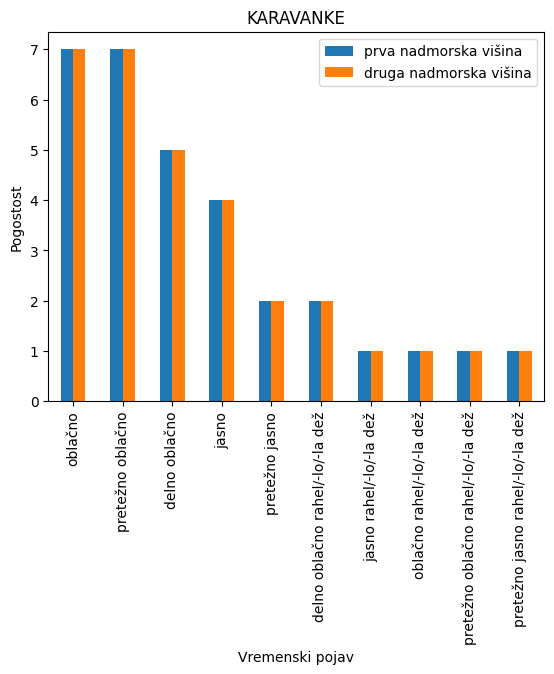

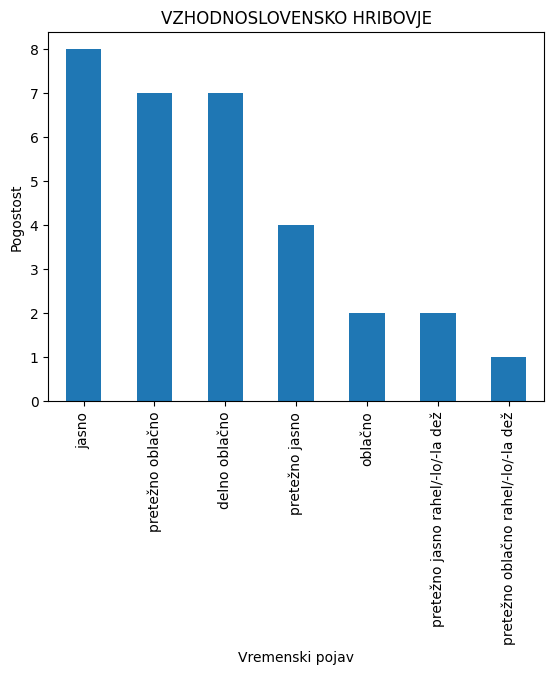

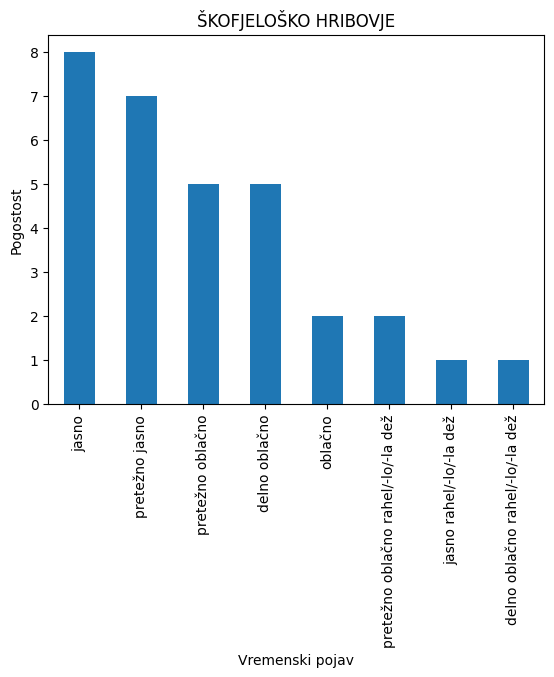

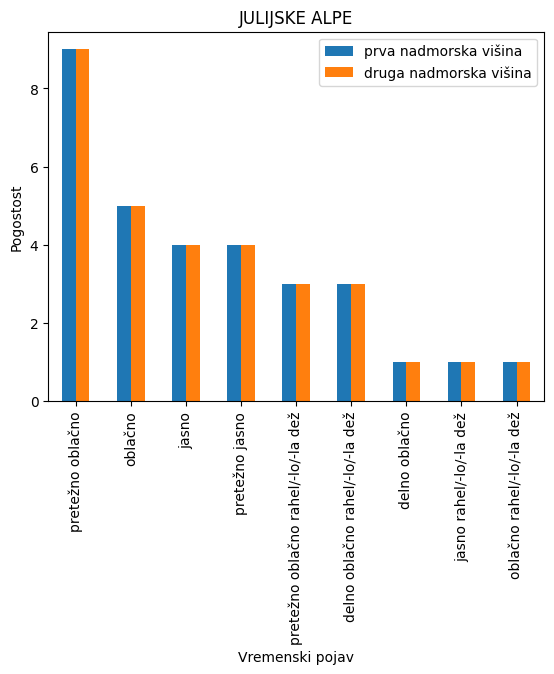

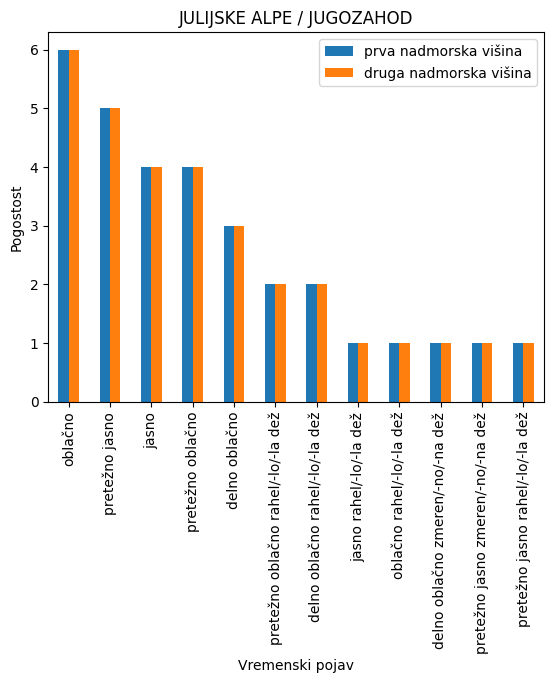

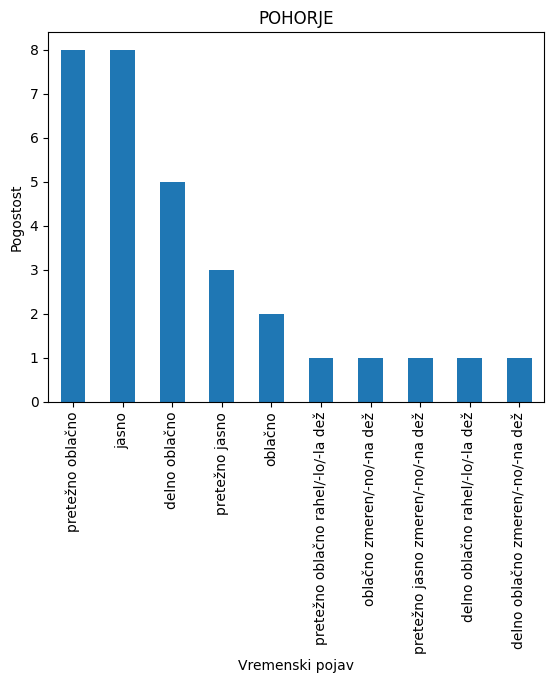

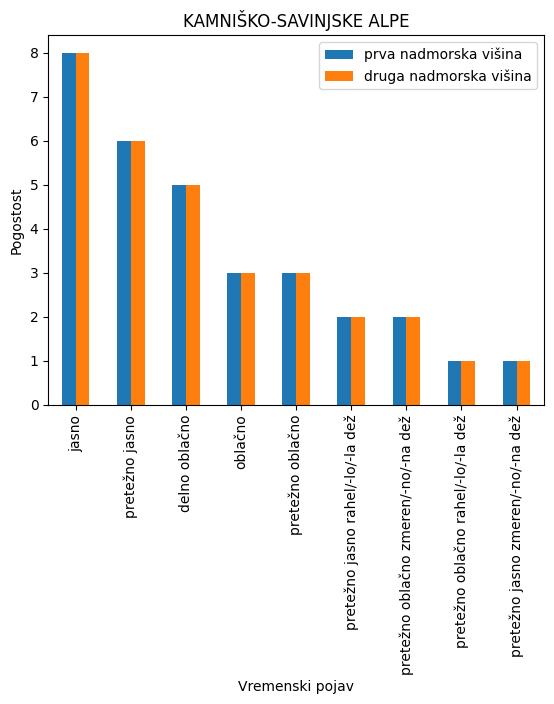

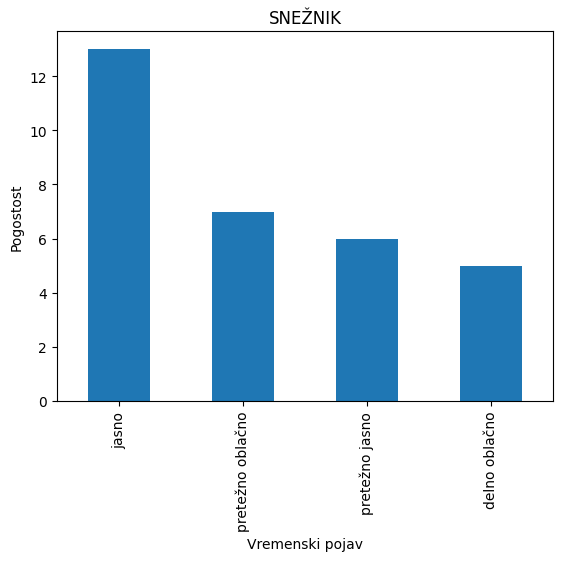

In [5]:
def analiza_vremena(gorovje = "vsa gorovja", dan = 4):
    """Funkcija sprejme neobvezna podatka o tem, za katero gorovje in za koliko dni nas zanima analiza vremena.
    Funkicja pove, kateri vremenski pojav, bo v izbranem časovnem obdobju najpogostejši 
    (privzeta podatka: gorovje = 'vsa gorovja' in dan = 4 (vedno imamo napoved, za največ 4 dni v naprej))"""

    seznam_df = vremenska_napoved(gorovje, dan)

    # S funkcijo value_counts razvrstimo podatke po pogostosti
    for data_frame in seznam_df:

        # Če podatka ni (včasih ni podatka za 2500) vrstica vrne False
        vrstica_2500 = data_frame[data_frame.iloc[:, 1].astype(str).str.contains("Vreme na 2500 m")]
        vrstica_1500 = data_frame[data_frame.iloc[:, 1].astype(str).str.contains("Vreme na 1500 m")]

        
        # V primeru, da podatki obstajajo, jih shranimo 
        # vreme na 1500
        if not vrstica_2500.empty:
            vreme_2500 = vrstica_2500.iloc[0, 2:].value_counts()
        else:
            vreme_2500 = ""

        # vreme na 1500 m
        if not vrstica_1500.empty:
            vreme_1500 = vrstica_1500.iloc[0, 2:].value_counts()

        else:
            vreme_1500 = ""


        # Načeloma je možna samo možnost, da podatki za 2500m ne obstajajo (če gorovje ni dovolj visoko)
        # V vsakem primer prilagodimo izbor podatkov glede na tko, kaj imamo na voljo

        if not vrstica_2500.empty and not vrstica_1500.empty:
            # podatke združimo v en data frame
            podatki = pd.DataFrame({
                "prva nadmorska višina": vreme_2500,
                "druga nadmorska višina": vreme_1500
            }).fillna(0)

        elif not vrstica_2500.empty and vrstica_1500.empty:
            podatki = vreme_2500
        elif not vrstica_1500.empty and vrstica_2500.empty:
            podatki = vreme_1500
        else:
            podatki = None

        ime_gorovja = str(data_frame.iloc[0,0])

        if podatki is not None:
            podatki.plot(kind="bar")
            plt.xlabel("Vremenski pojav")
            plt.ylabel("Pogostost")
            plt.title(f"{ime_gorovja}")

            plt.show()
        
analiza_vremena()

## Obravnavanje temperature
V tem poglavju se bomo posvetili analiziranju podatkov v zvezi s temperaturo. 

### Pomožne funkcije
Pogostokrat zajemamo in obdelujemo ene in iste podatke zato lahko sestavimo, določene pomožne funkcije.

**seznam_gorovij**: Funkcija ponuja možnost, da uporabnik ne pove specifičnega gorovja, za katerega ga zanima
    povprečna temperatura. V primeru, da ni navedel specifičnega gorovja izračunamo povprečje za 
    vsa gorovja skupaj

In [6]:
def seznam_gorovij(gorovje):
    """Funkcija sprejme argument gorovje vrne seznam vseh gorovjih, ki jih bomo obravnavali."""
    return list(set(df["JULIJSKE ALPE"])) if gorovje == "vsa gorovja" else [gorovje]

def zajem_temperature(ime_gorovja):
    """Funkcija sprejme ime gorovja in locira podatke o temperaturi za to gorovje"""
    zacetek = df.index[
                (df.iloc[:, 0].astype(str).eq(ime_gorovja)) &
                (df.iloc[:, 1].astype(str).eq("Temperatura"))
            ][0]
    
    konec = df.index[
        (df.index > zacetek) &
        (df.iloc[:, 1].isna())
    ][0]

    temperatura = df.loc[
        zacetek + 1:konec - 1
    ].copy()

    
    temperatura = temperatura.rename(
    columns={temperatura.columns[0]: ""})

    return temperatura

def predelaj_podatke(temperatura):
    """Funkcija spremeni podatke o temperaturi v številske podatke"""

    podatki = temperatura.iloc[:, 2:-1].copy()
    podatki = podatki.replace(r" °C", "", regex=True) 
    podatki = podatki.astype(float) 

    return podatki

# V nadaljevanju večkrat uporabimo



### Kako izgledajo podatki

In [7]:
display(zajem_temperature("KARAVANKE"))

,,Izračun: Sreda 26.08.2026 14 CEST,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
137,KARAVANKE,na 5500 m,-8 °C,-9 °C,-8 °C,-9 °C,-8 °C,-8 °C,-7 °C,-6 °C,...,-9 °C,-9 °C,-8 °C,-8 °C,-8 °C,-8 °C,-8 °C,-8 °C,-8 °C,-8 °C
138,KARAVANKE,na 3000 m,8 °C,8 °C,8 °C,10 °C,10 °C,11 °C,11 °C,12 °C,...,7 °C,6 °C,7 °C,6 °C,6 °C,7 °C,6 °C,5 °C,6 °C,7 °C
139,KARAVANKE,na 2500 m,11 °C,11 °C,11 °C,12 °C,14 °C,14 °C,15 °C,14 °C,...,9 °C,9 °C,10 °C,9 °C,9 °C,9 °C,9 °C,8 °C,9 °C,10 °C
140,KARAVANKE,na 2000 m,14 °C,14 °C,14 °C,13 °C,15 °C,18 °C,16 °C,17 °C,...,12 °C,12 °C,12 °C,12 °C,12 °C,12 °C,12 °C,12 °C,12 °C,13 °C
141,KARAVANKE,na 1500 m,17 °C,17 °C,16 °C,16 °C,16 °C,17 °C,19 °C,20 °C,...,14 °C,15 °C,17 °C,16 °C,15 °C,14 °C,14 °C,15 °C,14 °C,16 °C
142,KARAVANKE,na 1000 m,21 °C,20 °C,19 °C,18 °C,18 °C,21 °C,24 °C,24 °C,...,17 °C,20 °C,22 °C,19 °C,17 °C,17 °C,16 °C,15 °C,19 °C,21 °C
143,KARAVANKE,na 500 m,24 °C,23 °C,22 °C,22 °C,22 °C,24 °C,28 °C,28 °C,...,20 °C,23 °C,25 °C,23 °C,21 °C,20 °C,19 °C,19 °C,22 °C,25 °C


### Spreminjanje temperature skozi čas
Funkcija nihanje_temperature bo za izbrana gorovja prikazala, kako se spreminja temperatura na določeni nadmorski višini skozi čas.

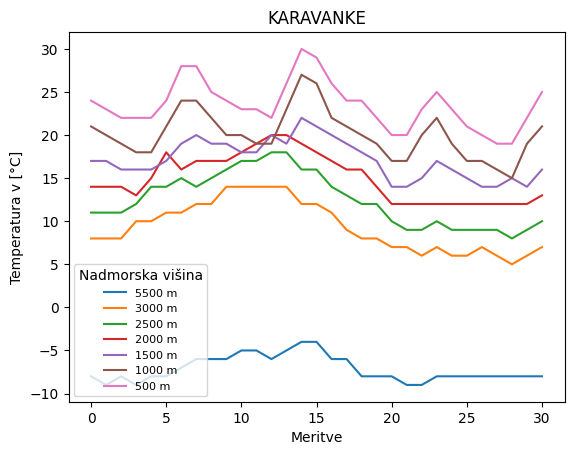

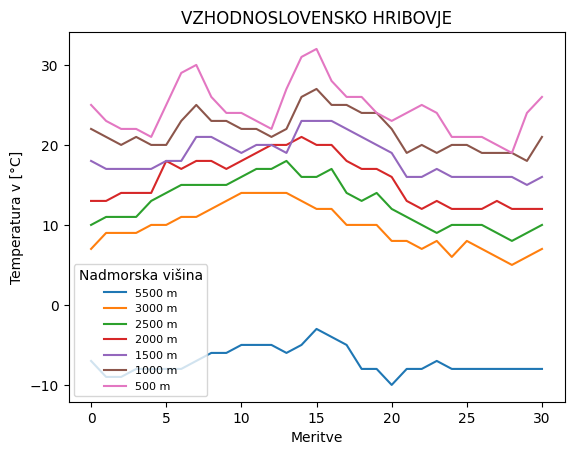

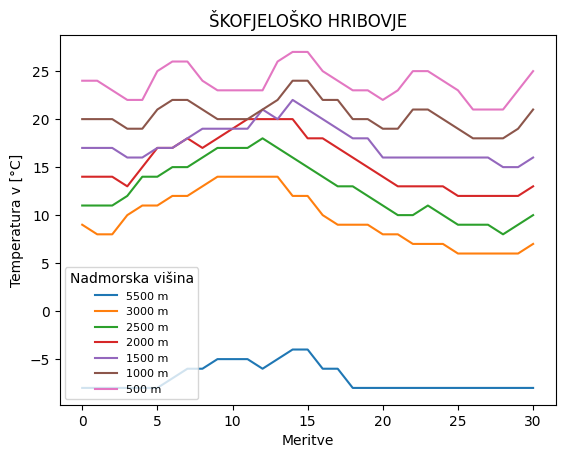

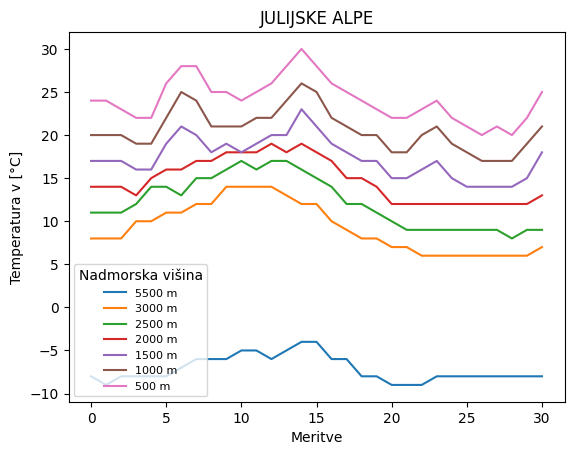

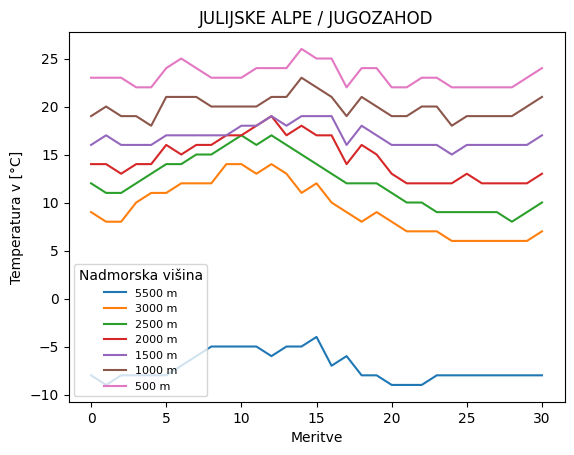

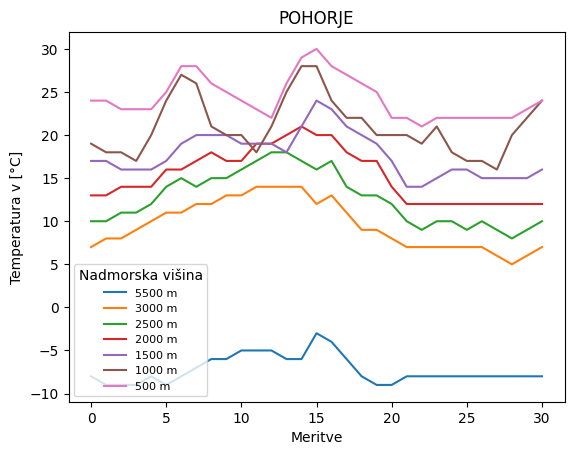

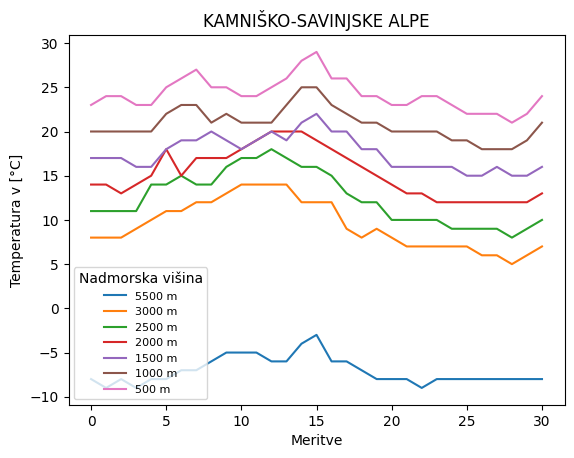

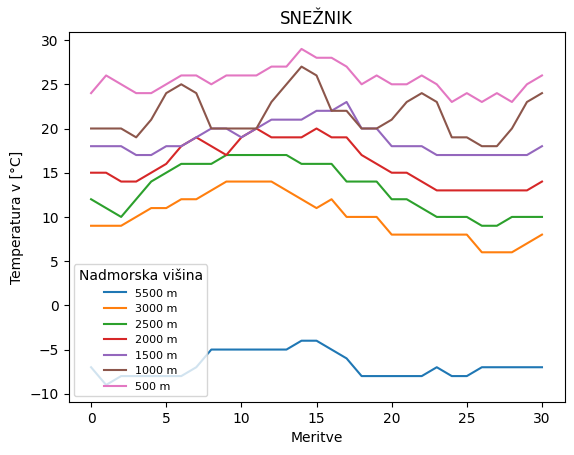

In [8]:
def nihanje_temperature(gorovje = "vsa gorovja"):

    "Funkcija sprejme neobvezen podatek o tem katero gorovje nas zanima in prikaže nihanje temperature skozi dneve, ki so na voljo."

    izbrana_gorovja = seznam_gorovij(gorovje)

    for ime_gorovja in izbrana_gorovja:
        temperatura = zajem_temperature(ime_gorovja)
        

        # Ta del funkcije izlušči podatek o nadmorski višini in ga kot integer doda tabeli. 
        temperatura["nadmorska_visina"] = (temperatura.iloc[:, 1].str.extract(r"(\d+)").astype(int))
        podatki = predelaj_podatke(temperatura)
        
        # za vsako nadmorsko višino narišemo graf
        for indeks, vrsta in podatki.iterrows():
            nadmorska_višina = temperatura.loc[indeks, "nadmorska_visina"]
            ypoints = list(vrsta)
            plt.xlabel("Meritve")
            plt.ylabel("Temperatura v [°C]")
            plt.title(f"{ime_gorovja}")
            plt.plot(ypoints, label = f"{nadmorska_višina} m")
            
        plt.legend(title="Nadmorska višina", loc="lower left", title_fontsize=10, fontsize=8)
        plt.show()

nihanje_temperature()


### Povprečna temperatura na določeni nadmorski višini
V tem poglavju nas bo zanimalo kakšna je povprečna temperatura na določeni višini v izbranem gorovju, kakšna je povprečna temperatura v izbranem gorovju in kakšna je povprečna temperatura v vseh gorovjih, ki jih obravnavamo.

In [9]:
def povprečna_temperatura(gorovje="vsa gorovja"):
    """Funkcija izračuna povprečno temperaturo na vsah nadmorskih višinah za neobvezen argument izbrano gotovje.
    (privzeta vrednost = "vsa gorovja")"""
   
    izbrana_gorovja = seznam_gorovij(gorovje)

    # V temu delu programa zajamemo številske podatke o temperaturi
    rezultati = []
    vse_temperature = []
    for ime_gorovja in izbrana_gorovja:
        temperatura = zajem_temperature(ime_gorovja)
        
        # Ta del funkcije izlušči podatek o nadmorski višini in ga kot integer doda tabeli.
        temperatura["nadmorska_visina"] = (temperatura.iloc[:, 1].str.extract(r"(\d+)").astype(int))

        # Tukaj poberemo temperaturne podatke, odstranimo oznako °C in jim spremenimo tip v float.
        podatki = predelaj_podatke(temperatura)

        # podatke shranjujemo zato, da lahko izračunamo povprečno temperaturo za vsa izbrana gorovja
        vse_temperature.append(podatki)

        # Povprečje za vsako višino, axis = 1 pomeni, da izračuna povprečje po vodoravnici, torej za določeno nadmorsko višino
        temperatura["povprecje"] = podatki.mean(axis=1)
        temperatura["skupno_povprecje"] = np.nanmean(podatki.to_numpy())
        rezultati.append(temperatura[["nadmorska_visina", "povprecje", "skupno_povprecje"]])

    # več data-frejmov se združi v en data frame
    vse_temperature = pd.concat(vse_temperature) 
    glavno_povprečje = np.nanmean(vse_temperature.to_numpy())

    return rezultati, glavno_povprečje, izbrana_gorovja


<Figure size 640x480 with 0 Axes>

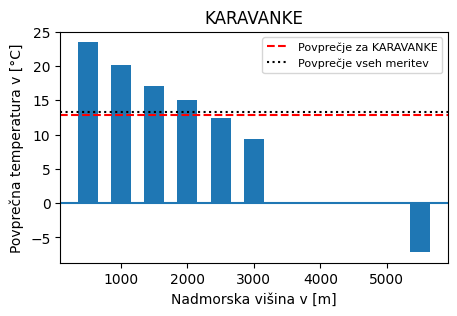

<Figure size 640x480 with 0 Axes>

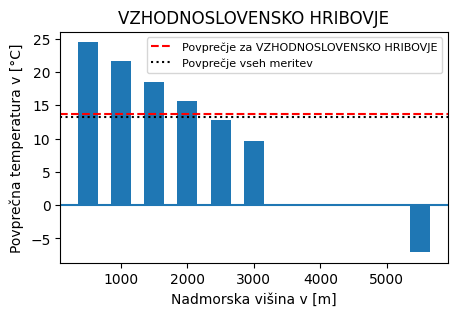

<Figure size 640x480 with 0 Axes>

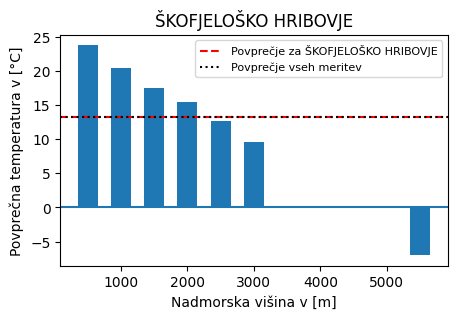

<Figure size 640x480 with 0 Axes>

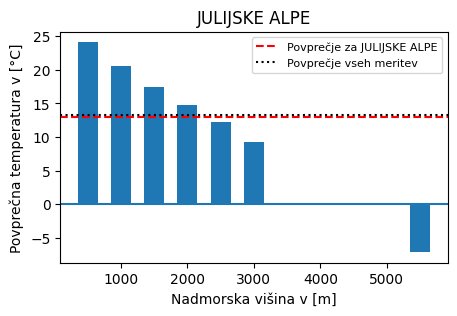

<Figure size 640x480 with 0 Axes>

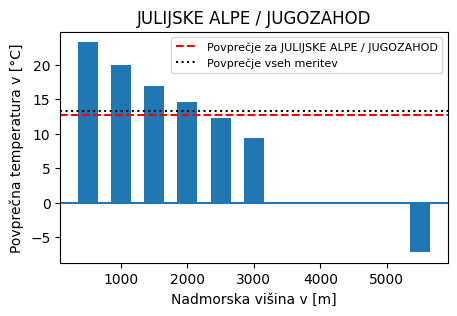

<Figure size 640x480 with 0 Axes>

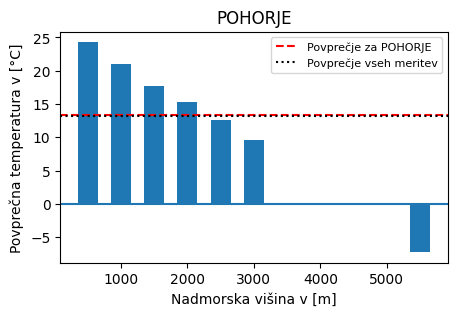

<Figure size 640x480 with 0 Axes>

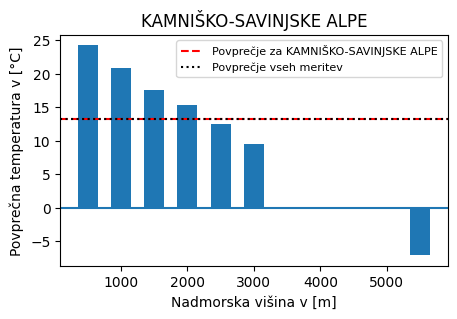

<Figure size 640x480 with 0 Axes>

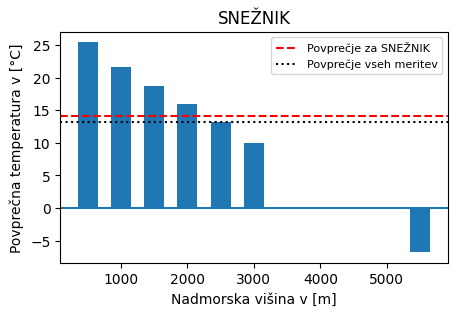

In [10]:
def graf_povprečna_temperatura(gorovje = "vsa gorovja"):
    """Funkcija nariše graf povprečne temperature glede na nadmorsko višino za neobvezen argument izbrana gorovja.
    (priveza vrednost = "vsa gorovja") """

    rezultati, glavno_povprečje, izbrana_gorovja = povprečna_temperatura(gorovje)

    # iteriramo po gorovjih, rezultati so seznam data frame-ov
    for i in range (len(rezultati)):
        x = rezultati[i]["nadmorska_visina"]
        y = rezultati[i]["povprecje"]

        plt.figure()
        plt.figure(figsize=(5, 3))

        # na garfu ponazorimo povprečno temperaturo za izbrano gorovje in za vsa izbrana gorovja
        plt.axhline(rezultati[i]["skupno_povprecje"].iloc[0], linestyle = '--', color = 'red', label = f"Povprečje za {izbrana_gorovja[i]}")
        plt.axhline(glavno_povprečje, linestyle = 'dotted', color = 'black', label = f"Povprečje vseh meritev")
        plt.axhline(0, linestyle = '-')

        plt.xlabel("Nadmorska višina v [m]")
        plt.ylabel("Povprečna temperatura v [°C]")
        plt.title(f"{izbrana_gorovja[i]}")
        plt.bar(x,y, width=300)
        plt.legend(loc="upper right", title_fontsize=10, fontsize=8)
        plt.show() 
        
graf_povprečna_temperatura()


### Interpretacija 22.8.2026
Funkcija `nihanje_temperature` je pokazala, da temperatura skozi čas na različnih nadmorskih višinah niha približno enako (črte na grafu so bolj ali manj vzporedne). Funkciji `povprečna_temperatura` in `graf_povprečne_temperature`,  pa sta pokazali, da temperatura z nadmorsko višino pada in da za vsa gorovje velja, da je temperatura na 5500m krepko pod ničlo. Poleg tega pa vidimo, da v nižjih gorovjih kot je npr. Snežnik je povprečna temperatura vseh gorovij precej manjša kot povprečna temperatura na snežniku.

## Obravnavanje vlažnosti
V tem poglavju bomo obravnavali, kako se vlažnost spreminja s nadmorsko višino in kako se spreminja časovno za izbrano gorovje. Na koncu bomoobravnavali tudi odvisnost vlage od temperature.

### Pomožne funkcije
Ker dvakrat zajemamo iste podatke na enak način napišemo pomožne funkcije.

In [11]:
def zajem_vlage(ime_gorovja):
    """Funkcija sprejme ime gorovja in locira podatke o temperaturi za to gorovje"""
    zacetek = df.index[
        (df.iloc[:, 0].astype(str).eq(ime_gorovja)) &
        (df.iloc[:, 1].astype(str).eq("Vlažnost"))
    ][0]
    konec = df.index[
        (df.index > zacetek) &
        (df.iloc[:, 1].isna())
    ][0]
    vlažnost = df.loc[
        zacetek + 1:konec - 1
    ].copy()

    
    vlažnost = vlažnost.rename(
    columns={vlažnost.columns[0]: ""})

    return vlažnost

def predelaj_podatke_vlaga(vlažnost):
    """Funkcija spremeni podatke o vlagi v številske podatke"""
    podatki = vlažnost.iloc[:, 2:-1].copy()
    podatki = podatki.replace(r" %", "", regex=True) 
    podatki = podatki.astype(float) 
    return podatki

def ustvari_df(vlažnost, dan):

    """Pomožna funkcija ustvari data frame, ki ima za stolpce imena dnevov za vsebino pa povprečno vlago na 
    izbran dan v nadmorski višini """
    nov_df = pd.DataFrame()
    podatki = predelaj_podatke_vlaga(vlažnost)
    
    # nadmorska višina ostane prvi stolpec
    nov_df["nadmorska_visina"] = vlažnost["nadmorska_visina"]
    # Določimo kateri dan je danes
 
    for i in range(dan + 1):
        # poiščemo vse stolpce, ki pripadajo temu dnevu
        stolpci_dneva = [
            stolpec
            for stolpec in podatki.columns
            if str(stolpec).startswith(krajšave[(danes_indeks + i) % 7] + " ")
        ]
        if not stolpci_dneva:
            continue
        
        # vzamemo podatke vseh ur tega dne
        vrednosti = podatki[stolpci_dneva].copy()

        # pretvorimo v številke
        vrednosti = vrednosti.apply(pd.to_numeric,errors="coerce")

        # nov data farme vsebuje podatke o povprečni vlagi na določeni nadmorski višini za vse izbrane dneve
        # povprečje po vrsticah = povprečje za vsako nadmorsko višino
        nov_df[krajšave[(danes_indeks + i) % 7]] = vrednosti.mean(axis=1)
        
    return nov_df

### Kako izgledajo podatki

In [12]:
display(zajem_vlage("KAMNIŠKO-SAVINJSKE ALPE"))

,,Izračun: Sreda 26.08.2026 14 CEST,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
121,KAMNIŠKO-SAVINJSKE ALPE,na 5500 m,50 %,55 %,59 %,43 %,39 %,47 %,37 %,40 %,...,12 %,13 %,12 %,34 %,34 %,17 %,23 %,36 %,46 %,45 %
122,KAMNIŠKO-SAVINJSKE ALPE,na 3000 m,60 %,63 %,58 %,53 %,39 %,39 %,50 %,52 %,...,63 %,61 %,57 %,64 %,70 %,54 %,58 %,65 %,70 %,61 %
123,KAMNIŠKO-SAVINJSKE ALPE,na 2500 m,58 %,62 %,63 %,60 %,44 %,36 %,45 %,49 %,...,66 %,75 %,62 %,61 %,77 %,64 %,65 %,80 %,81 %,70 %
124,KAMNIŠKO-SAVINJSKE ALPE,na 2000 m,64 %,58 %,64 %,70 %,62 %,39 %,73 %,48 %,...,83 %,87 %,75 %,61 %,85 %,76 %,77 %,84 %,90 %,79 %
125,KAMNIŠKO-SAVINJSKE ALPE,na 1500 m,76 %,58 %,67 %,73 %,70 %,73 %,75 %,73 %,...,88 %,82 %,80 %,74 %,78 %,81 %,76 %,81 %,84 %,77 %
126,KAMNIŠKO-SAVINJSKE ALPE,na 1000 m,85 %,75 %,66 %,76 %,74 %,64 %,64 %,64 %,...,80 %,72 %,72 %,81 %,80 %,82 %,81 %,83 %,76 %,68 %
127,KAMNIŠKO-SAVINJSKE ALPE,na 500 m,86 %,78 %,66 %,76 %,74 %,63 %,63 %,63 %,...,79 %,71 %,71 %,82 %,81 %,80 %,81 %,82 %,75 %,68 %


### Spreminjanje vlage s časom za izbrano gorovje in nadmorsko višino
 
 Sestavili bomo funkcijo, ki za izbrano gorovje prikaže spreminjanje vlage na določeni nadomrski višini, skozi dneve za katere imamo napoved.

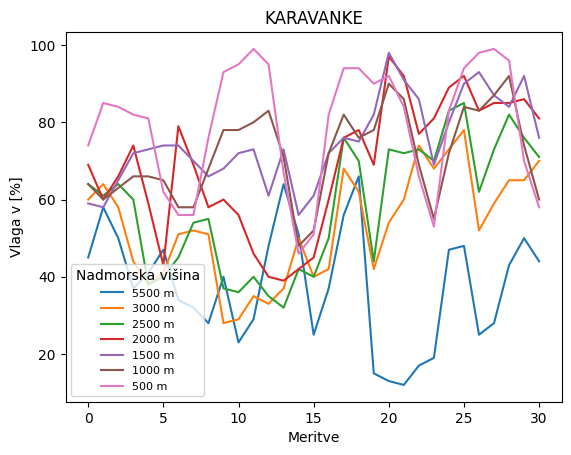

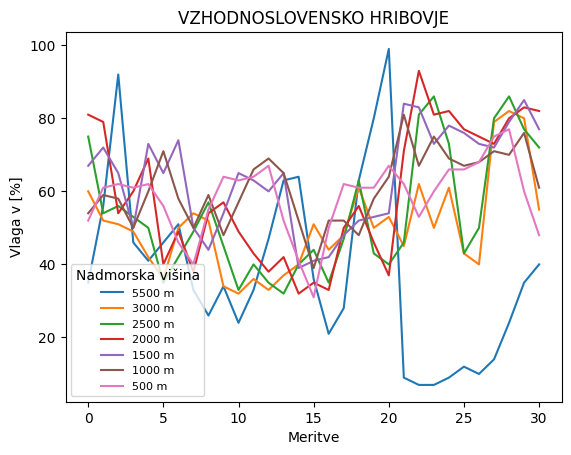

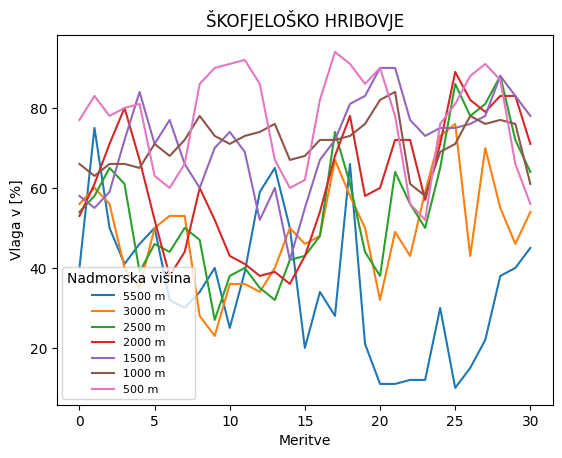

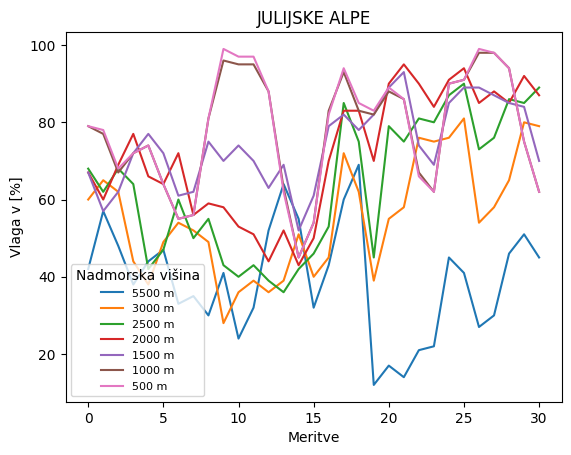

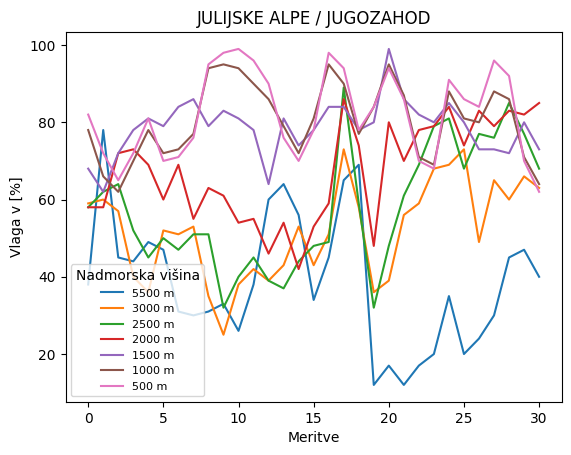

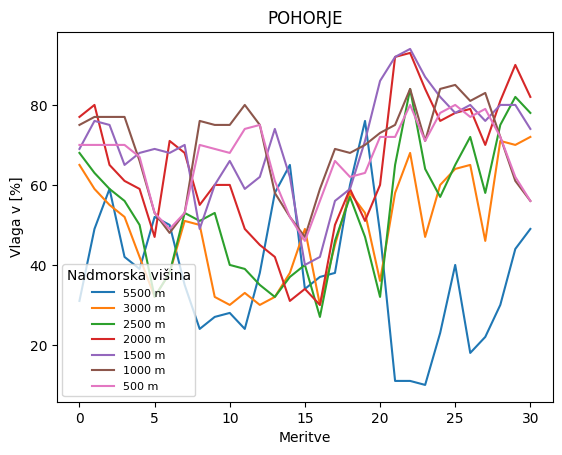

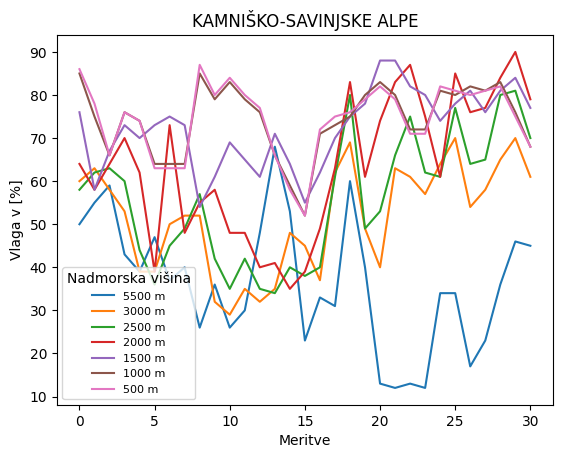

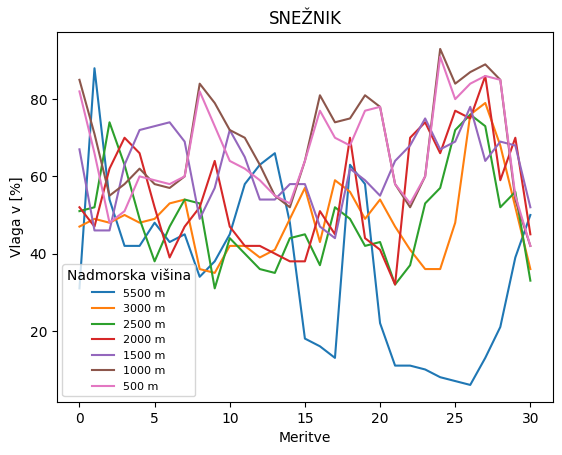

In [13]:
def časovno_spreminjanje_vlage(gorovje = "vsa gorovja", visina = "vse visine"):
    """Funkcija sprejme neobezna podatka o gorovju in nadmorski višini (pribzeti vrednosti: "vsa gorovja", "vse visine") in
    nariše graf spreminjanja skozi čas"""

    izbrana_gorovja = seznam_gorovij(gorovje)

    for ime_gorovja in izbrana_gorovja:
    
        vlažnost = zajem_vlage(ime_gorovja)

        # Ta del funkcije izlušči podatek o nadmorski višini in ga kot integer doda tabeli.
        vlažnost["nadmorska_visina"] = (vlažnost.iloc[:, 1].str.extract(r"(\d+)").astype(int))
        podatki = predelaj_podatke_vlaga(vlažnost)

        # Ta del funkcije iterira po vrsticah podatkov, torej po nadmorskih višinah in za vsako vrstico nariše črto
        for indeks, vrstica in podatki.iterrows():
            nadmorska_višina = vlažnost.loc[indeks, "nadmorska_visina"]
            if nadmorska_višina == visina or visina == "vse visine":
                ypoints = list(vrstica)
                plt.xlabel("Meritve")
                plt.ylabel("Vlaga v [%]")
                plt.title(f"{ime_gorovja}")
                plt.plot(ypoints, label = f"{nadmorska_višina} m")
        plt.legend(title="Nadmorska višina", loc="lower left", title_fontsize=10, fontsize=8)
        plt.show()
            
časovno_spreminjanje_vlage()

### Spreminjanje vlage z nadmorsko višino
Sestavili bomo funkcijo, ki prikaže spreminajnje vlage glede na nadmorsko višino. Za podatke o vlagi na izbrani nadomrski višini izberemo povprečje vseh izmerjenih vrednosti vlage za tisti dan.

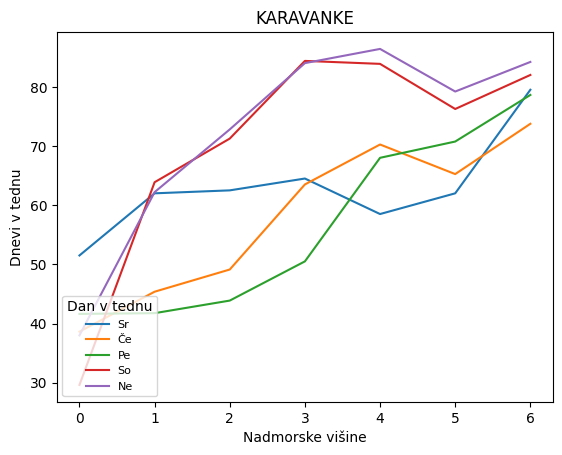

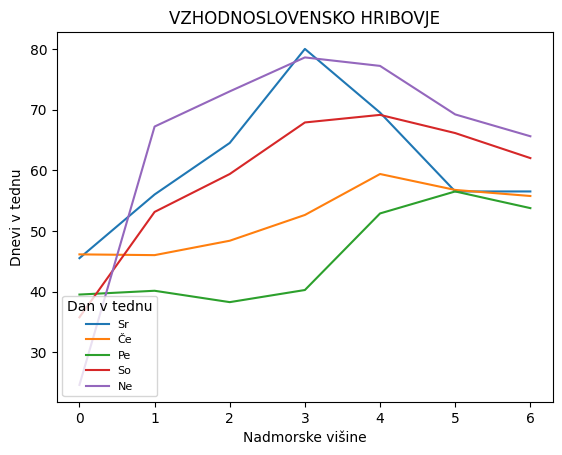

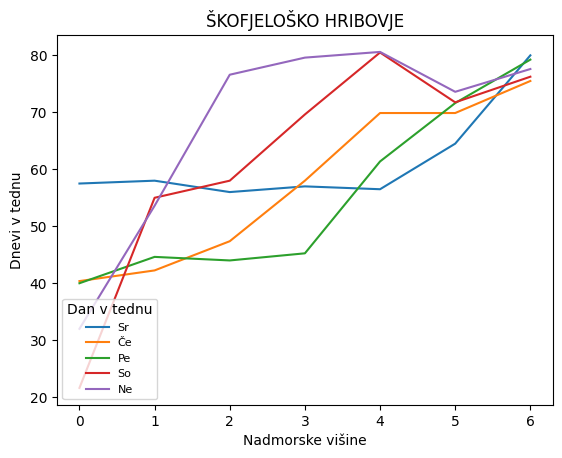

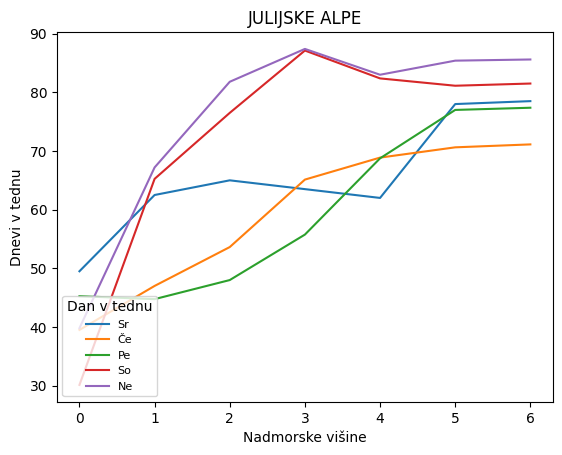

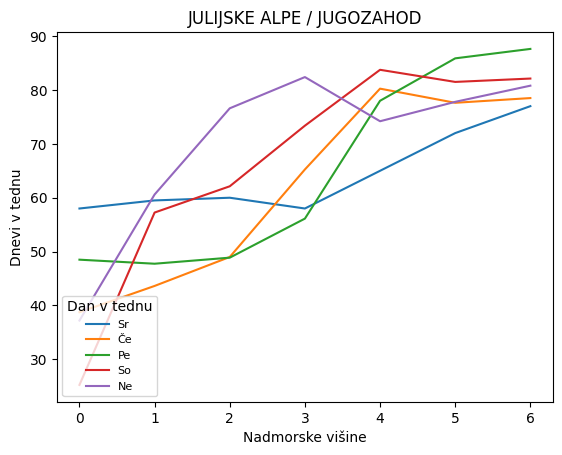

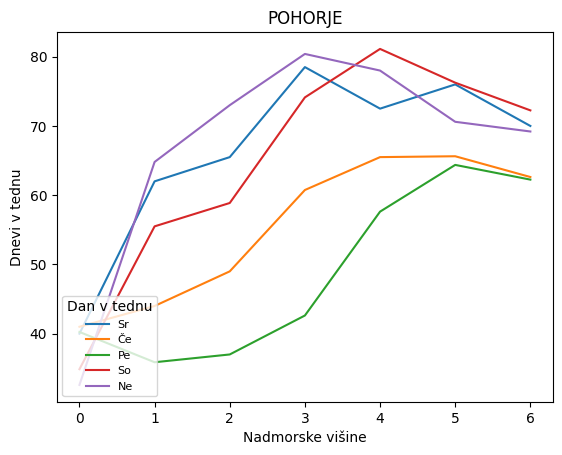

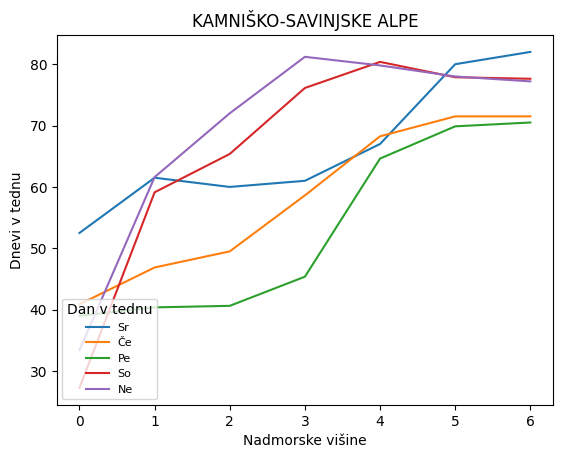

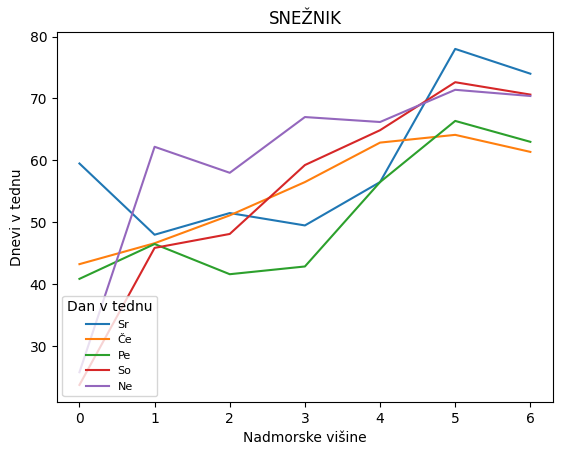

In [ ]:
def višinsko_spreminjanje_vlage(gorovje = "vsa gorovja", dan = 4):
    """Funkcija sprejme neobvezna argumenta gorovje in dan (privzeti vrednosti: "vsa gorovja", 4), ter prikaže, kako se za izbrane dneve
    z nadmorsko višino spreminja vlaga. """

    izbrana_gorovja = seznam_gorovij(gorovje)

    
    for ime_gorovja in izbrana_gorovja:
    
        vlažnost = zajem_vlage(ime_gorovja)

        # Ta del funkcije izlušči podatek o nadmorski višini in ga kot integer doda tabeli.
        vlažnost["nadmorska_visina"] = (vlažnost.iloc[:, 1].str.extract(r"(\d+)").astype(int))
        
        # iloc[:, 1:] prvi stolpec novega data frame-a vsebuje podatke o nadmorski višini, ki tukaj ne pridejo v poštev
        for ime_stolpca, stolpec in ustvari_df(vlažnost, dan).iloc[:, 1:].items():
            ypoints = list(stolpec)
            plt.xlabel("Nadmorske višine")
            plt.ylabel("Dnevi v tednu")
            plt.title(f"{ime_gorovja}")
            plt.plot(ypoints, label = ime_stolpca)

        plt.legend(title="Dan v tednu", loc="lower left", title_fontsize=10, fontsize=8)
        plt.show()

višinsko_spreminjanje_vlage()

### Interpretacija 22.8
Analiza je pokazala, da se vlaga na vseh nadmorskih višinah s časom spreminja približno enako (črte na grafu so si v grobem blizu). Podobno velja, da se vlaga z nadmorsko višino spreminja vsak dan približno enako, čeprav so možna tudi močna odstopanja. Opazimo tudi, da vlaga pada za nadmorsko visino.

## Povezava med vlago in temperaturo
Sestavili bomo funkcijo, ki bo pokazala, ali je kakšna korelacija med vlago in temperturo.

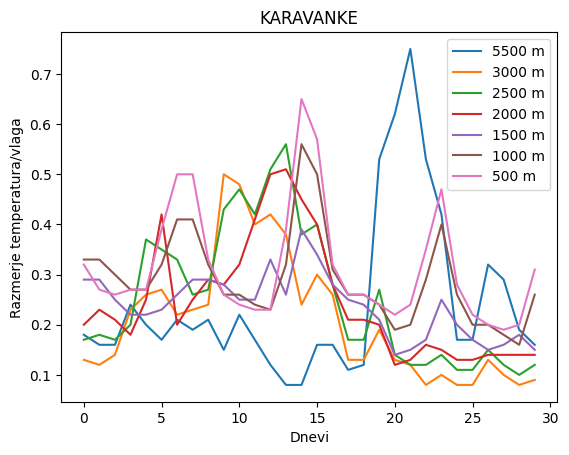

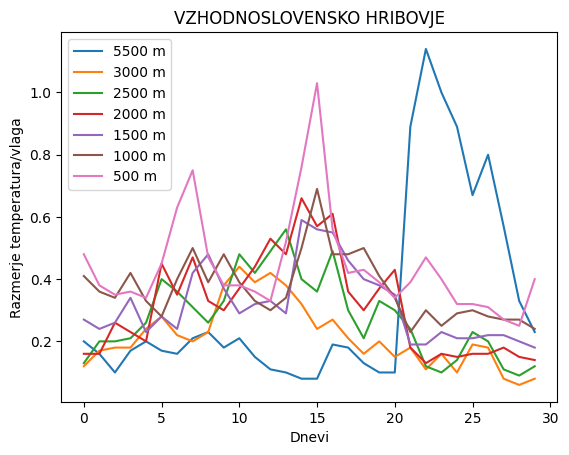

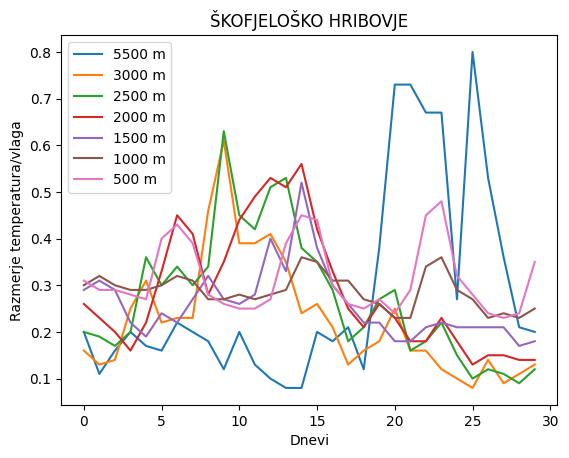

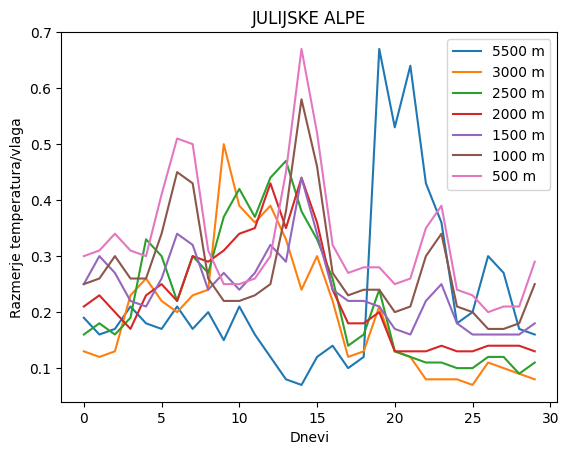

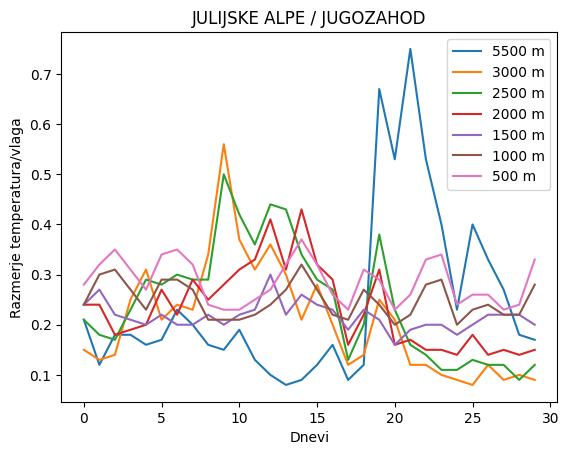

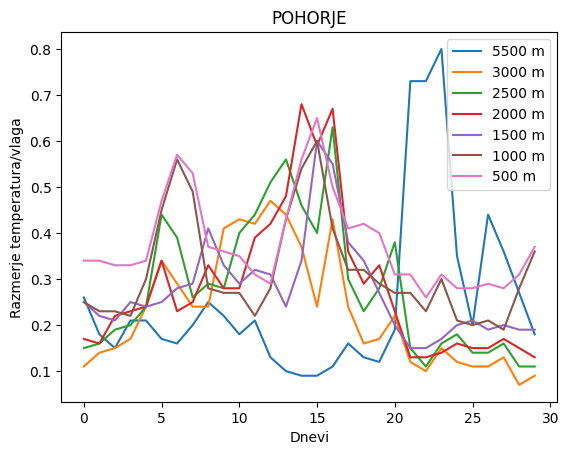

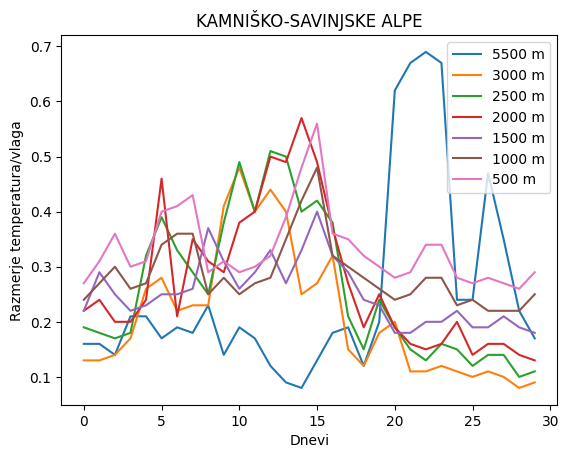

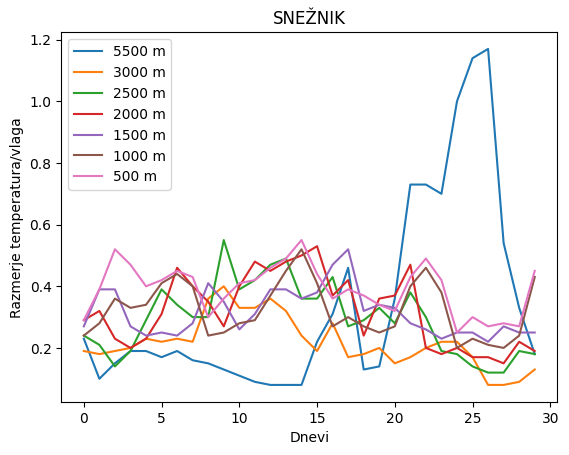

In [15]:
def vlaga_temperatura(gorovje = "vsa gorovja"):
    """Funkcija sprejme neobvezen argument ime gorovja (privzeta vrednost: vsa gorovja) in prikaže koeficiente |temperatura/ vlaga|"""
    izbrana_gorovja = seznam_gorovij(gorovje)

    for ime_gorovja in izbrana_gorovja:
        # Izluščimo nadmorsko višino
        temperatura = zajem_temperature(ime_gorovja)

        temperatura["nadmorska_visina"] = (
                    temperatura.iloc[:, 1]
                    .str.extract(r"(\d+)")
                    .astype(int)
                )

        # zajamemo podatke za vlago in temperaturo
        podatki_t = predelaj_podatke(zajem_temperature(ime_gorovja))
        podatki_v = predelaj_podatke_vlaga(zajem_vlage(ime_gorovja))

        podatki_t = podatki_t.reset_index(drop=True)
        podatki_v = podatki_v.reset_index(drop=True)

        količniki = abs((podatki_t / podatki_v).round(2))
        
        for indeks, vrsta in količniki.iterrows():
            nadmorska_višina = temperatura.iloc[indeks]["nadmorska_visina"]
            ypoints = list(vrsta)

            plt.xlabel("Dnevi")
            plt.ylabel("Razmerje temperatura/vlaga")
            plt.title(f"{ime_gorovja}")
            plt.plot(ypoints, label = f"{nadmorska_višina} m")

        plt.legend()
        plt.show()

    
vlaga_temperatura()


### Interpretacija 22.8.2026

Grafi so pokazali, da je količnik med vlago in temperaturo ponavadi podoben. Količniki najbolj odstopajo pri nadmorski višini 5500m in 500m

## Obravnavanje vetra
V tem poglavju se bomo ukvarjali s tem, v katero smer najpogosteje piha veter, kako se hitrost vetra spreminja z nadmorsko višino in kako se spreminja s časom.

### Pomožne funckije

In [16]:
def zajem_vetra(ime_gorovja):
    zacetek = df.index[
        (df.iloc[:, 0].astype(str).eq(ime_gorovja)) &
        (df.iloc[:, 1].astype(str).eq("Veter"))
    ][0]
    konec = df.index[
        (df.index > zacetek) &
        (df.iloc[:, 1].isna())
    ][0]
    veter = df.loc[
        zacetek + 1:konec - 1
    ].copy()
    
    veter = veter.rename(columns={veter.columns[0]: ""})

    return veter

def predelaj_podatke_veter(veter):
    """Tukaj poberemo podatke o vlagi, odstranimo oznako % in jim spremenimo tip v float."""
    podatki = veter.iloc[:, 2:].copy()
    podatki = podatki.replace(r" km/h", "", regex=True) 
    podatki = podatki.astype(float) 
    return podatki



### Kako izgledajo podatki

In [17]:
display(zajem_vetra("POHORJE").head(5))

,,Izračun: Sreda 26.08.2026 14 CEST,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
193,POHORJE,na 5500 m,močan zahod,zmeren zahod,zmeren zahod,močan zahod,močan severo-zahod,močan zahod,močan zahod,močan severo-zahod,...,močan zahod,močan zahod,močan zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod
194,POHORJE,hitrost,75 km/h,51 km/h,35 km/h,55 km/h,72 km/h,69 km/h,67 km/h,65 km/h,...,85 km/h,82 km/h,71 km/h,49 km/h,42 km/h,41 km/h,37 km/h,38 km/h,34 km/h,28 km/h
195,POHORJE,na 3000 m,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren severo-zahod,zmeren severo-zahod,zmeren zahod,zmeren zahod,...,zmeren jugo-zahod,zmeren jugo-zahod,zmeren jugo-zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,rahel jugo-zahod,rahel jugo-zahod
196,POHORJE,hitrost,27 km/h,31 km/h,32 km/h,26 km/h,27 km/h,40 km/h,35 km/h,33 km/h,...,51 km/h,51 km/h,46 km/h,28 km/h,21 km/h,20 km/h,24 km/h,20 km/h,14 km/h,16 km/h
197,POHORJE,na 2500 m,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren zahod,zmeren severo-zahod,zmeren zahod,zmeren zahod,...,zmeren jugo-zahod,zmeren jugo-zahod,zmeren jugo-zahod,zmeren jugo-zahod,zmeren zahod,zmeren zahod,zmeren zahod,rahel zahod,rahel jugo-zahod,rahel jugo-zahod


### Najpogostejša smer pihanja vetra
Funkcija bo s tortnim diagramom prikazal v katero smer najpogosteje piha veter, za vsak dan, ki je na voljo.

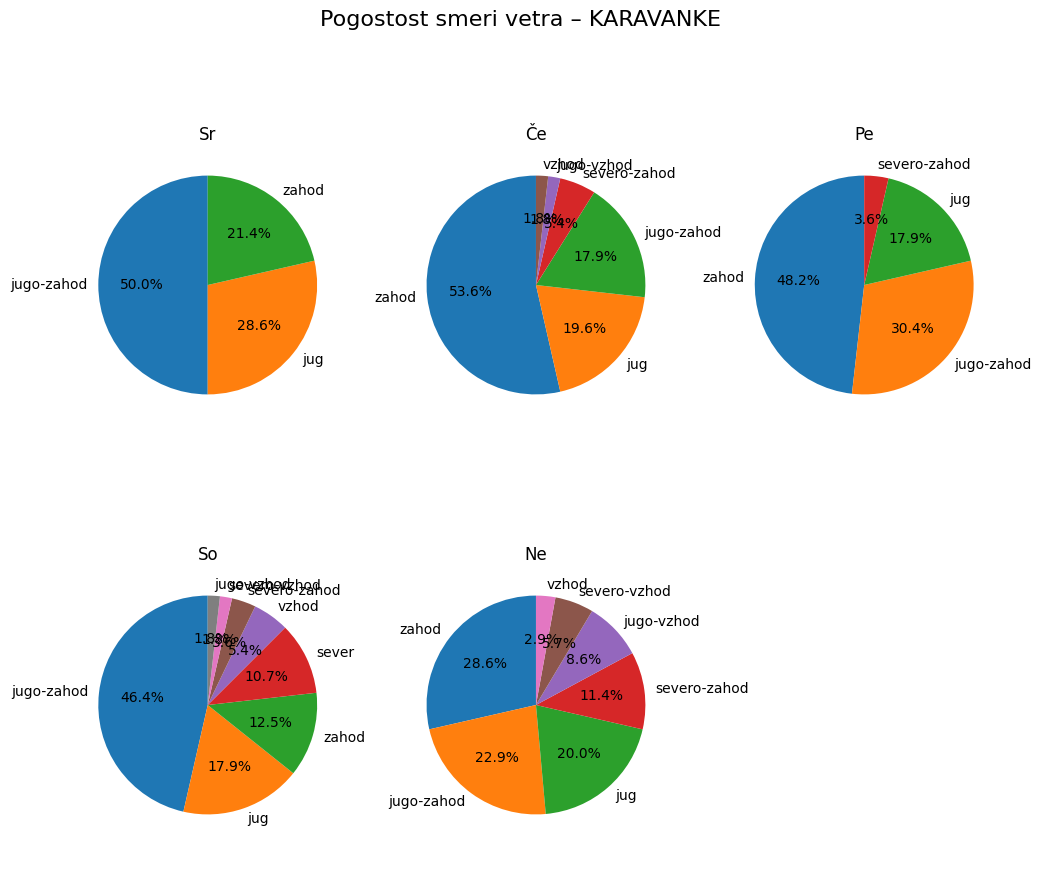

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

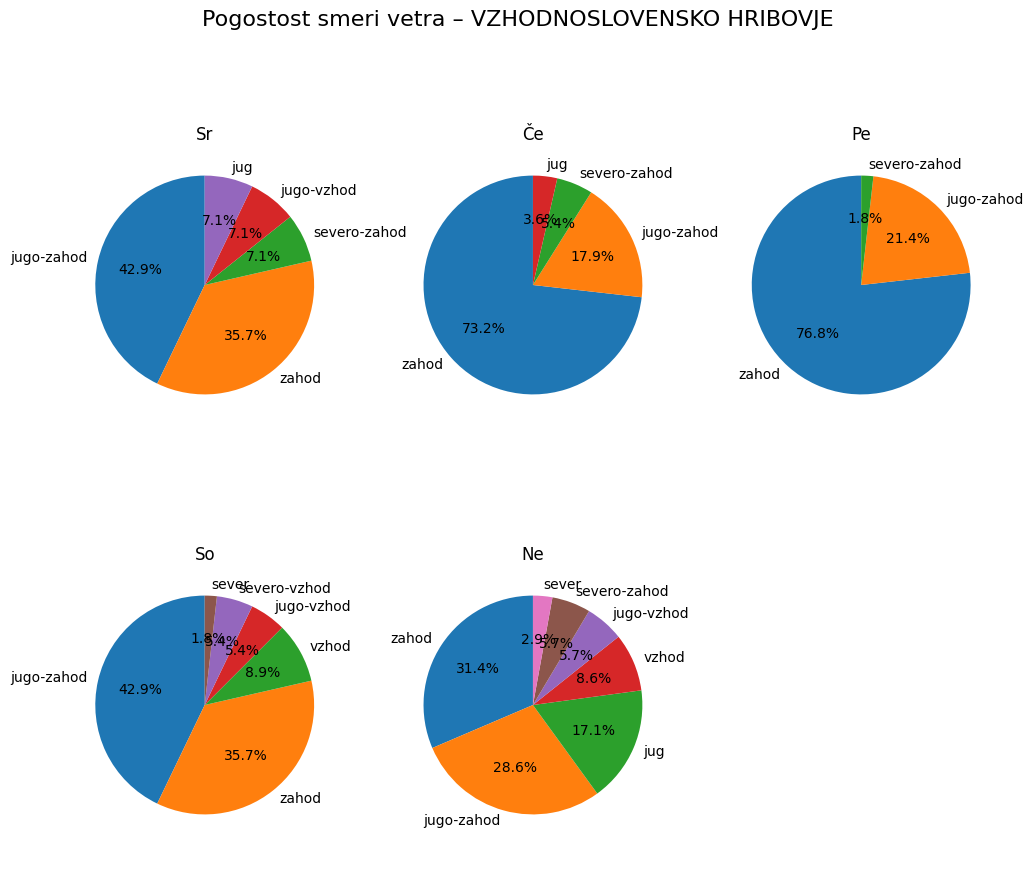

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

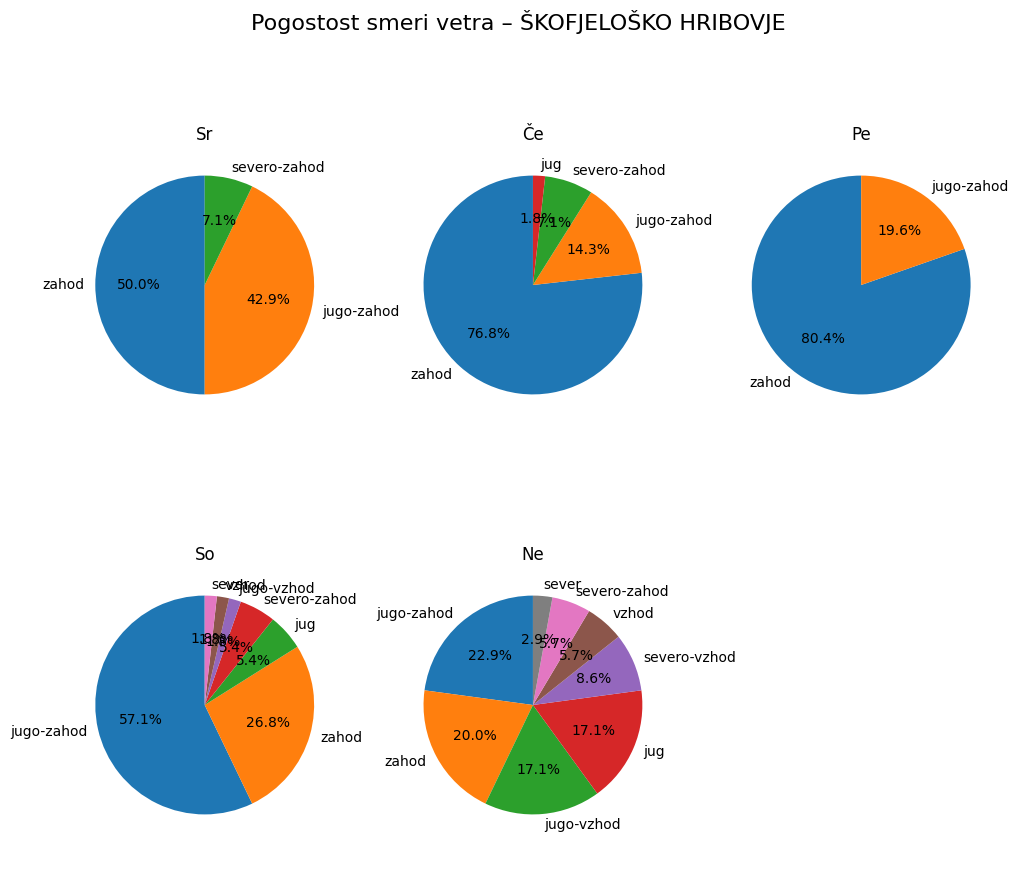

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

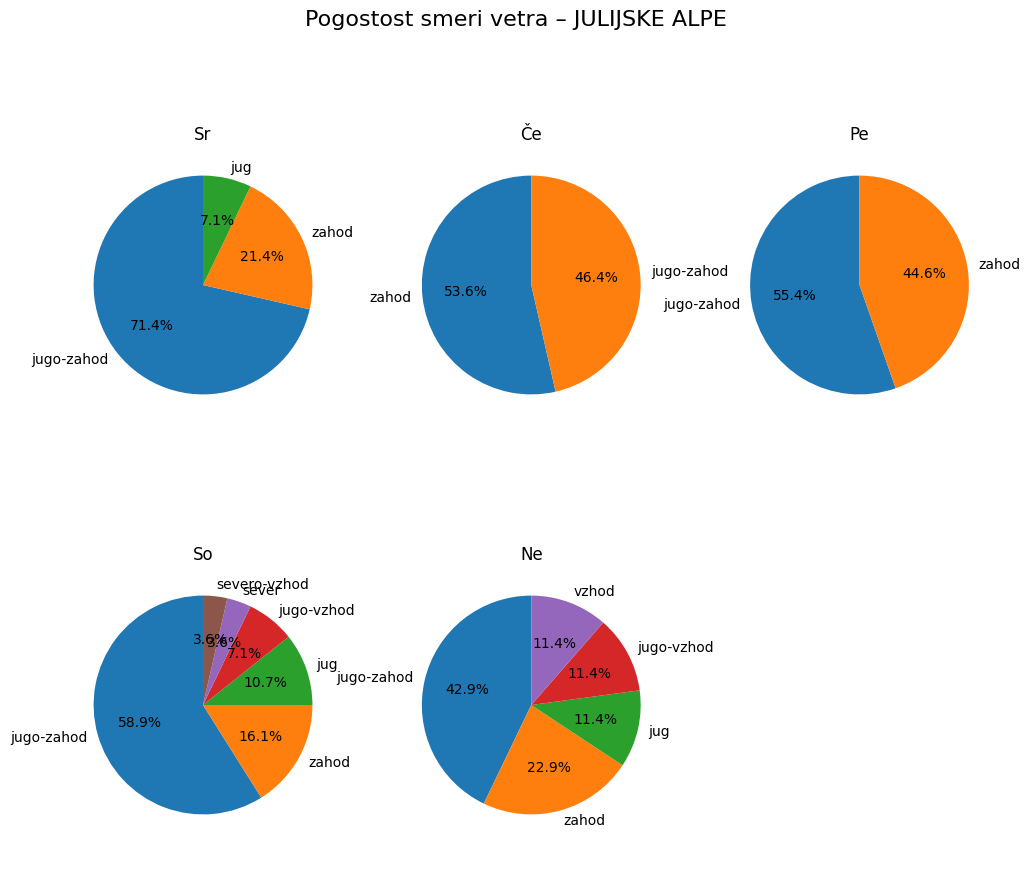

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

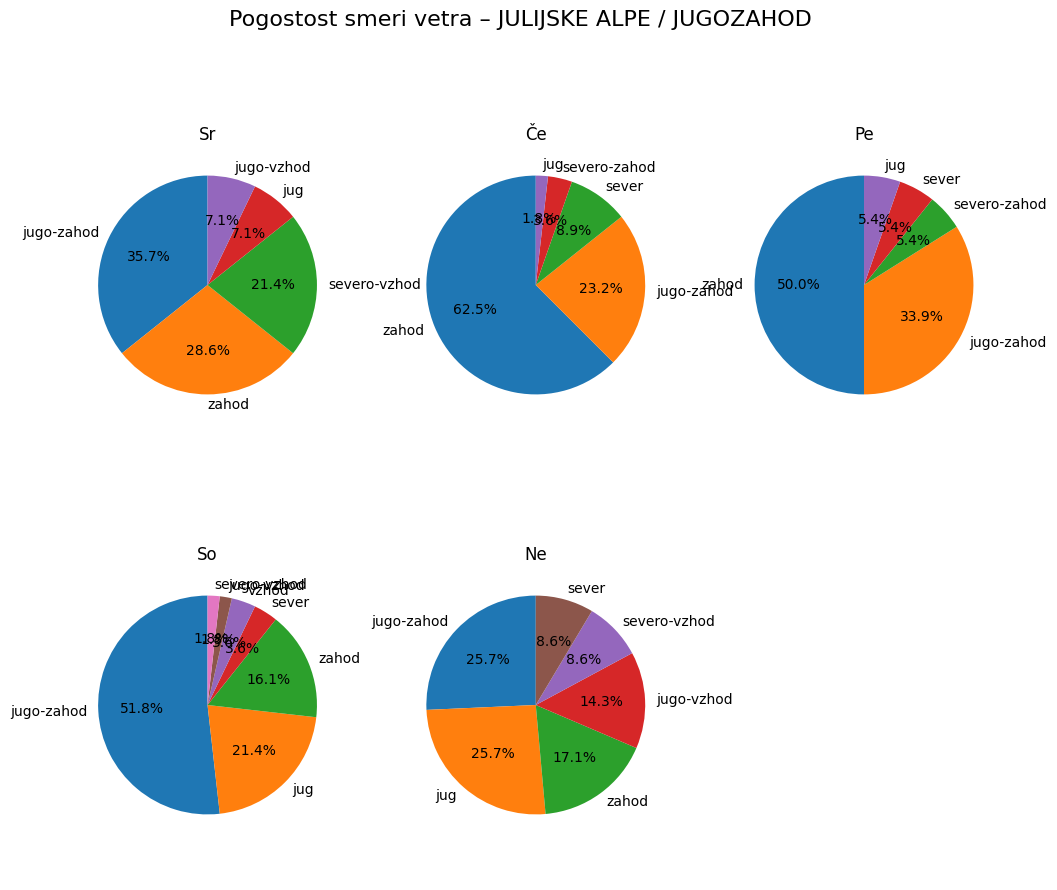

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

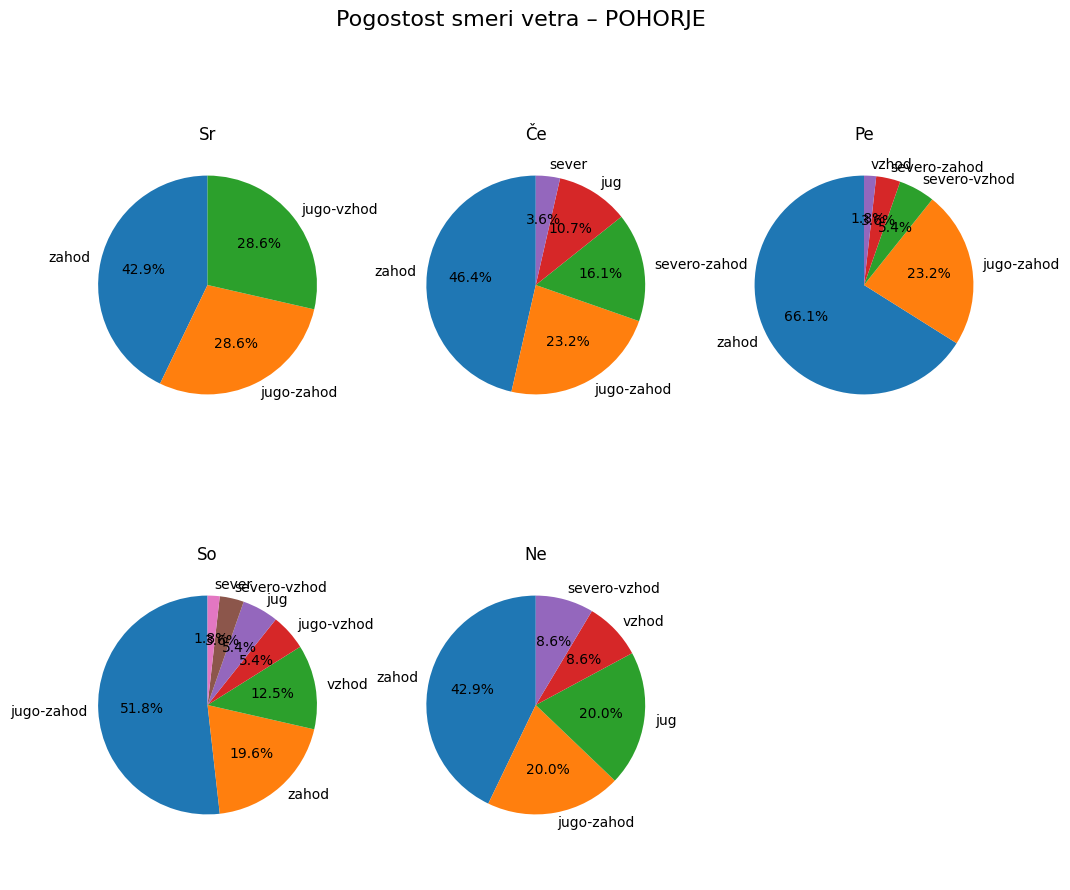

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

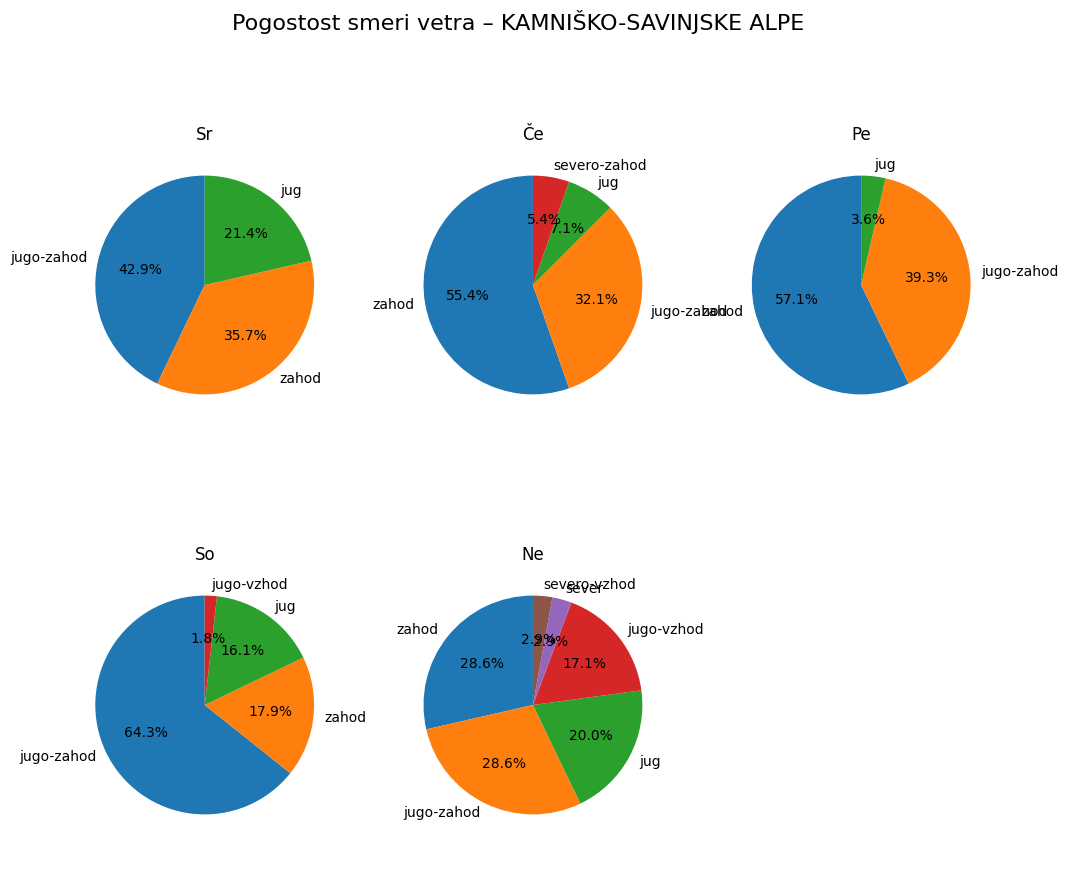

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

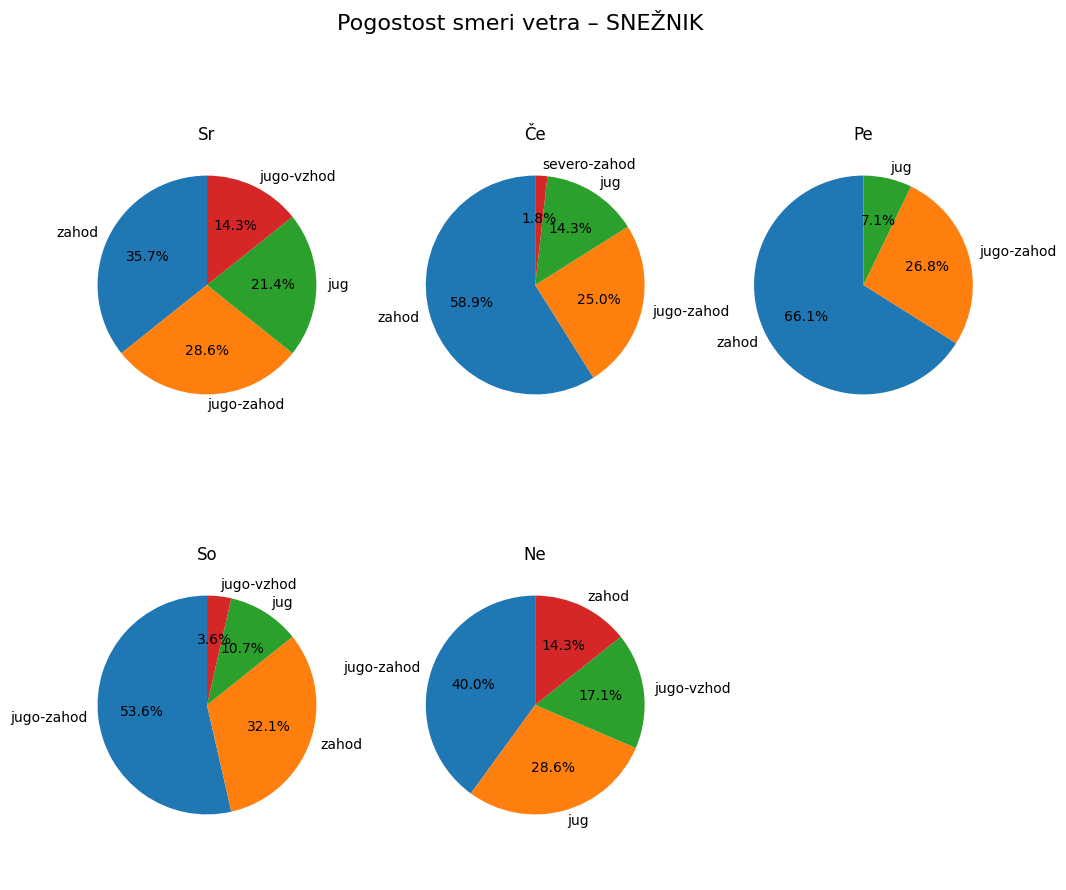

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

In [18]:
def pogoste_smeri(gorovje = "vsa gorovja", dan = 4):
    """Funkcija sprejme neobvezna argumenta gorovje in dan (privezi vrednoti: "vsa gorovja", 4) in prikaže 
    v katero smer za izbrane dneve najpogosteje v izbranem gorovju najpogosteje piha veter."""

    izbrana_gorovja = seznam_gorovij(gorovje)
    
    for ime_gorovja in izbrana_gorovja:

        veter = zajem_vetra(ime_gorovja)

        # podatki o vetru so izmenicno stevilski in opisni, tukaj potrebujemo le opisne
        opisni_podatki = veter.iloc[0::2].copy()

        # izlusicmo podatke o nadmorski visini
        opisni_podatki["nadmorska_visina"] = (opisni_podatki.iloc[:, 1].str.extract(r"(\d+)").astype(int))

        # Ustvarimo eno figuro s 2-6 grafi
        if dan == 0:
            fig, axes = plt.subplots(1, 1, figsize=(7, 7), squeeze=False)
        elif dan == 1:
            fig, axes = plt.subplots(1, 2, figsize=(12, 10), squeeze=False)
        elif dan == 2 or dan == 3:
            fig, axes = plt.subplots(2, 2, figsize=(12, 10), squeeze=False)
        elif dan == 4:
            fig, axes = plt.subplots(2, 3, figsize=(12, 10), squeeze=False)

        grafi = axes.flatten()


        for i in range(dan + 1):

            # poiščemo vse meritve za izbran dan
            stolpci_dneva = [
                stolpec
                for stolpec in opisni_podatki.columns
                if str(stolpec).startswith(krajšave[(danes_indeks + i) % 7] + " ")
            ]
            if not stolpci_dneva:
                continue

            # vzamemo podatke vseh ur tega dne
            vrednosti = opisni_podatki[stolpci_dneva].copy()

            #jakost vetra nas ne zanima
            vrednosti = vrednosti.replace({r"močan ": "",r"rahel ": "", r"zmeren ": ""}, regex=True)

            #določimo pogostost vsake smeri
            pogostost =  vrednosti.stack().value_counts()
            
            plt.figure(figsize=(7, 7))
            grafi[i].pie(
                pogostost.values,
                labels=pogostost.index,
                autopct="%1.1f%%",
                startangle=90
            )
            grafi[i].set_title(krajšave[(danes_indeks + i) % 7])

        if dan == 2:
            grafi[3].axis("off")
        elif dan == 4:
            grafi[5].axis("off")

        fig.suptitle(f"Pogostost smeri vetra – {ime_gorovja}", fontsize=16)

        plt.tight_layout()
        plt.show()
       
pogoste_smeri()

### Kako se spreminja hitrost vetra z nadmorsko višino
Funkcija obravnava podatke o hitrosti vetra. Pogleda hitrosti na različnih nadmorskih višinah izmerjene v dnevu, ter izračuna povprečno hitrost vetra, na izbrani nadmorski višini za izbran dan. To počne zato, da nimam preveč podatkov, saj jih je težko prikazati. Funkcija potem povprečne hitrosti vetra, za izbrano nadmorsko višino predstavi s stolpičnim diagramom.

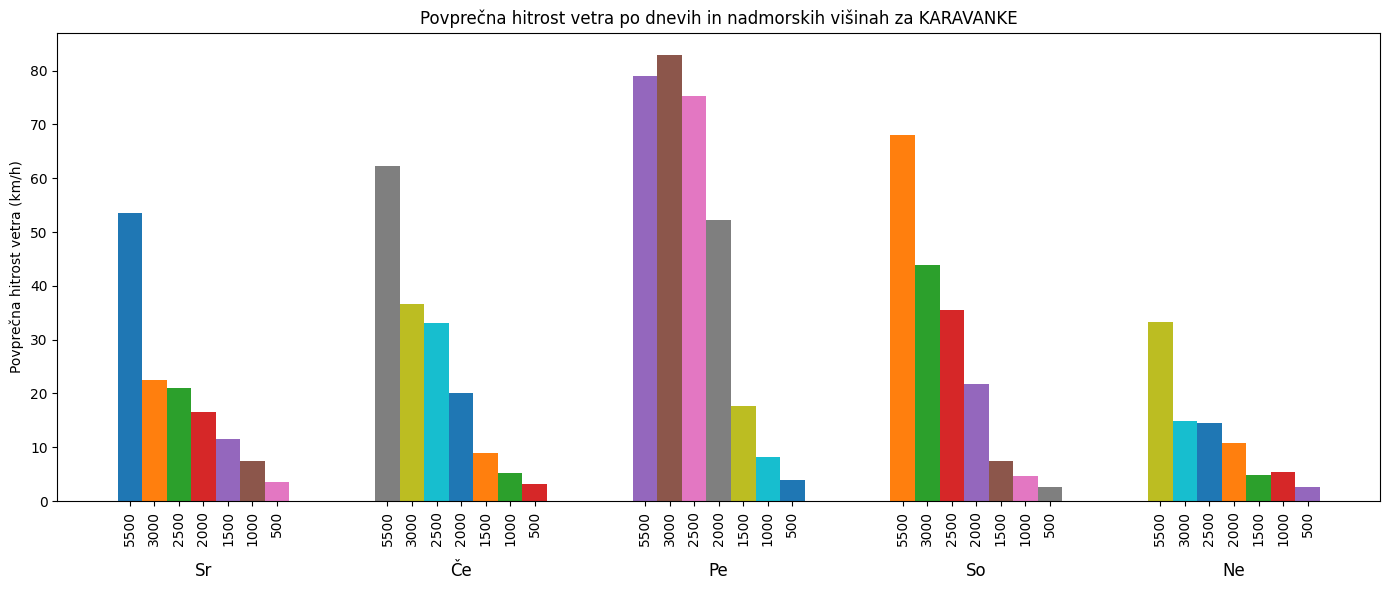

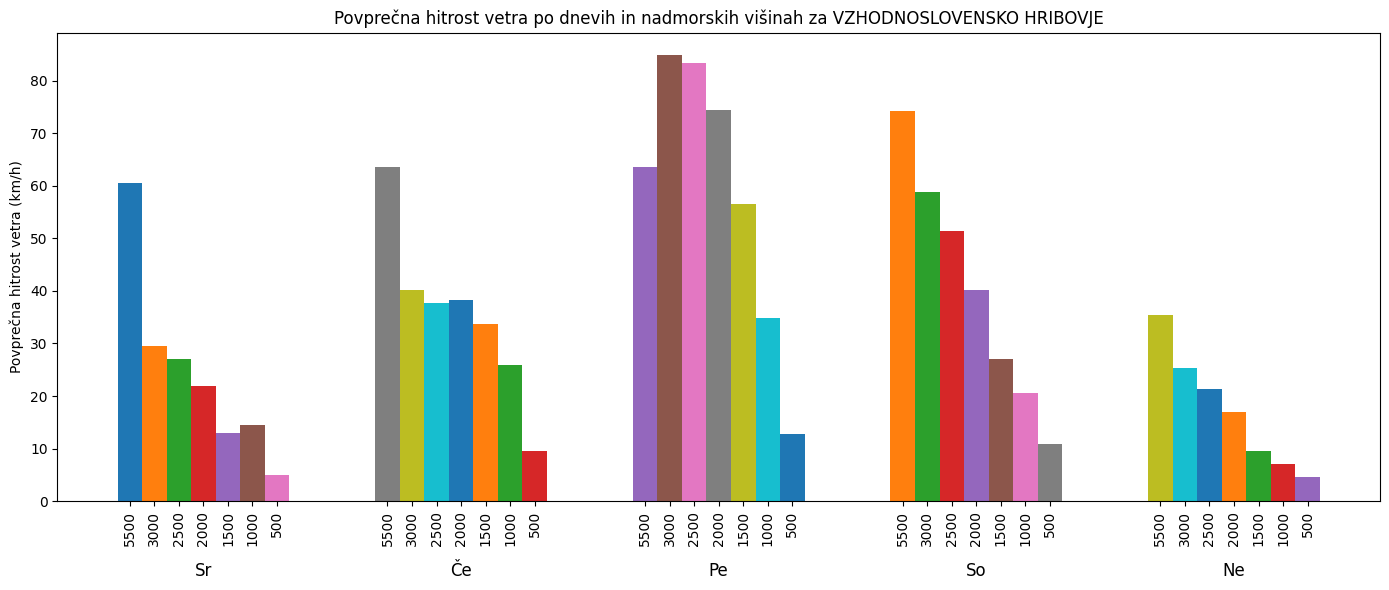

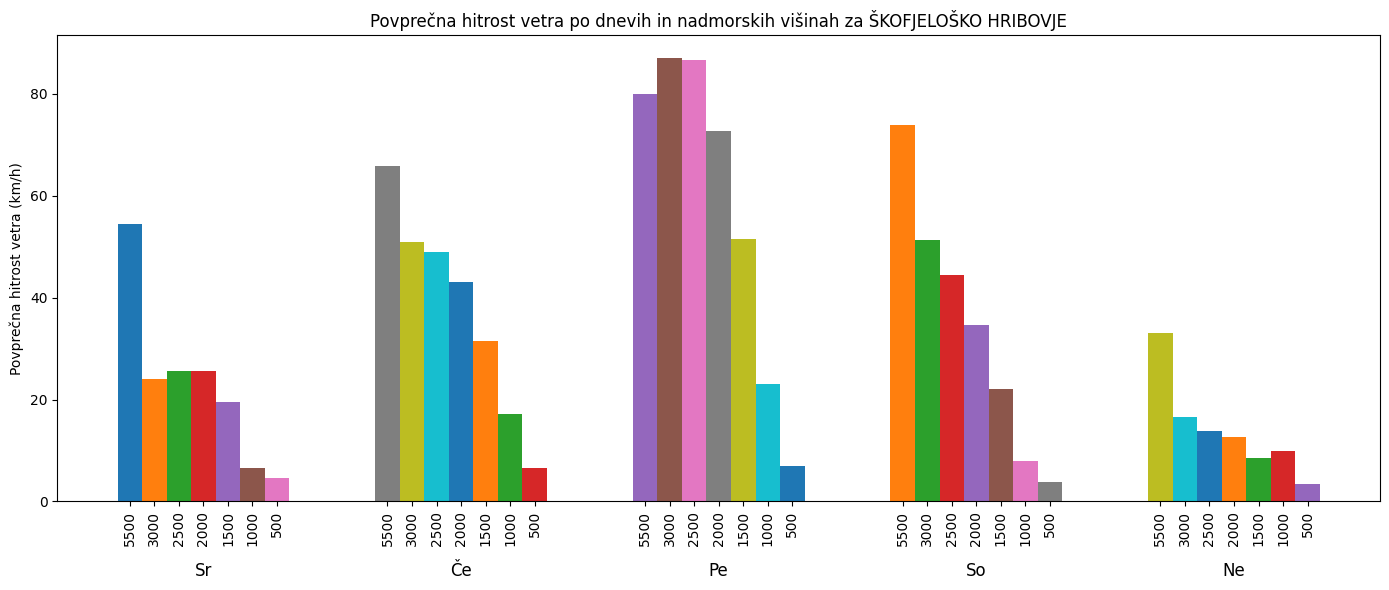

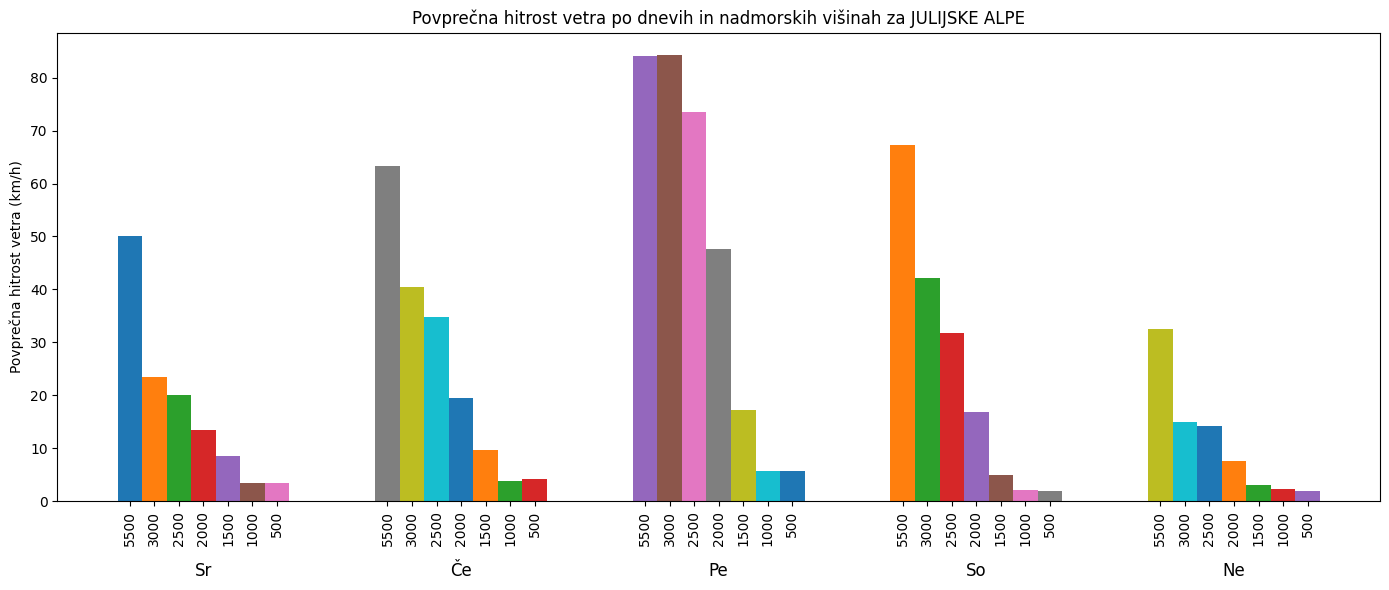

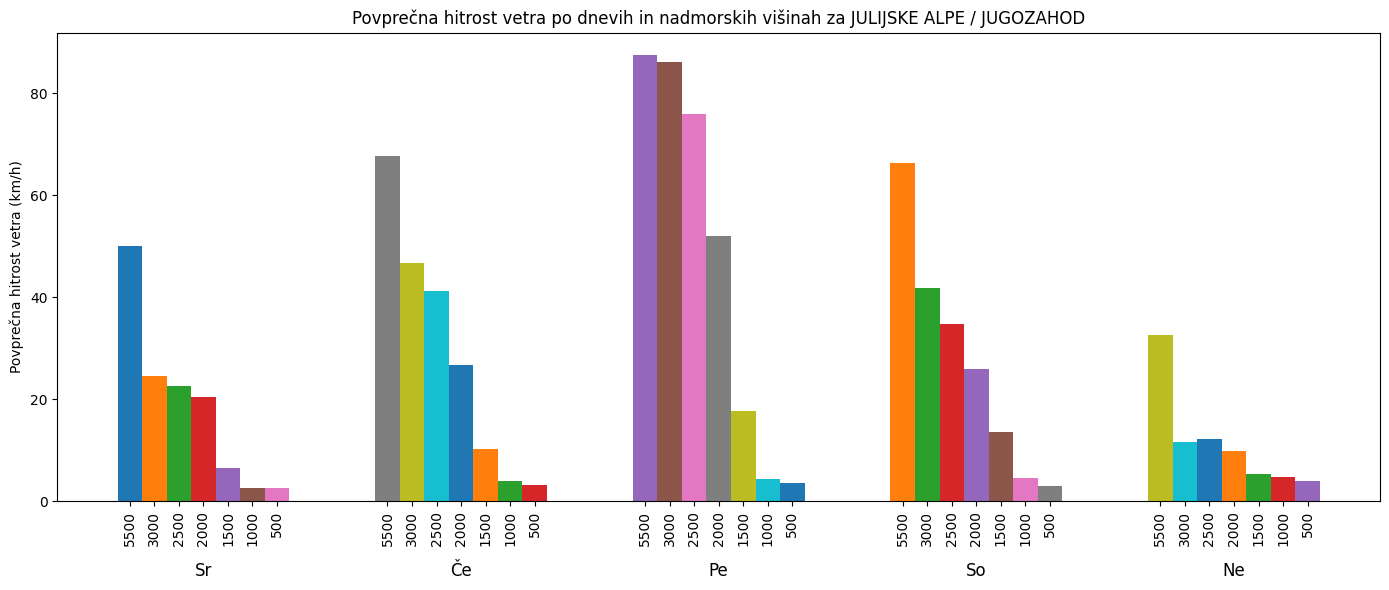

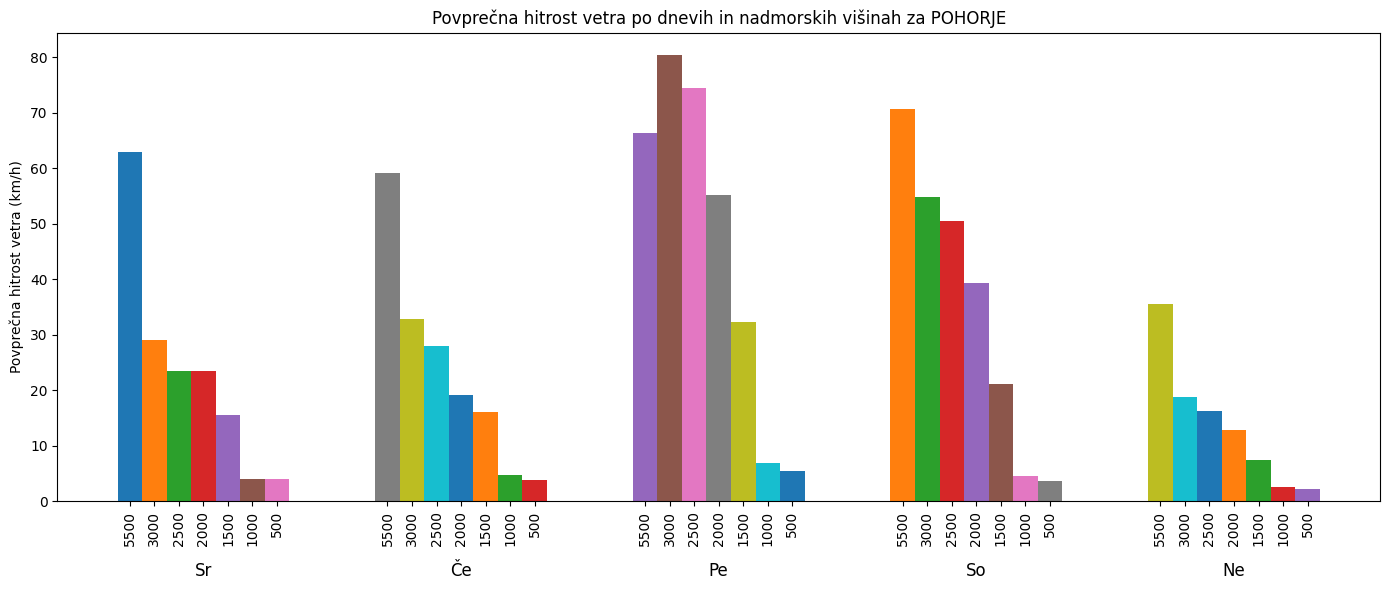

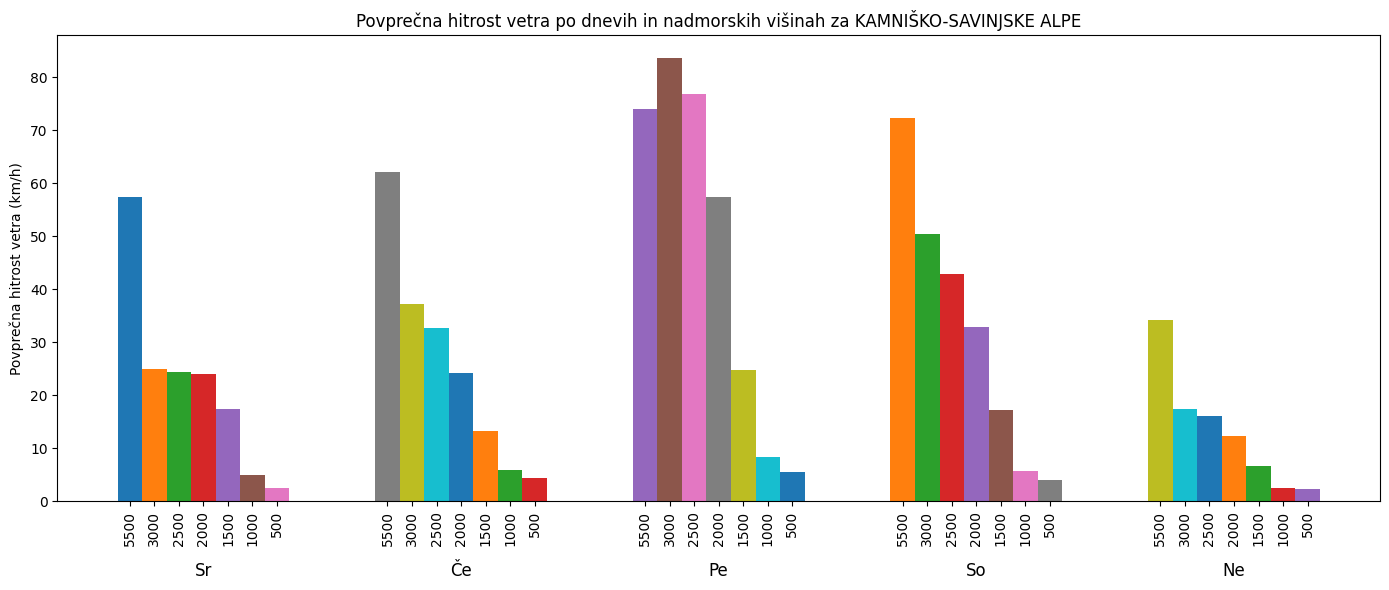

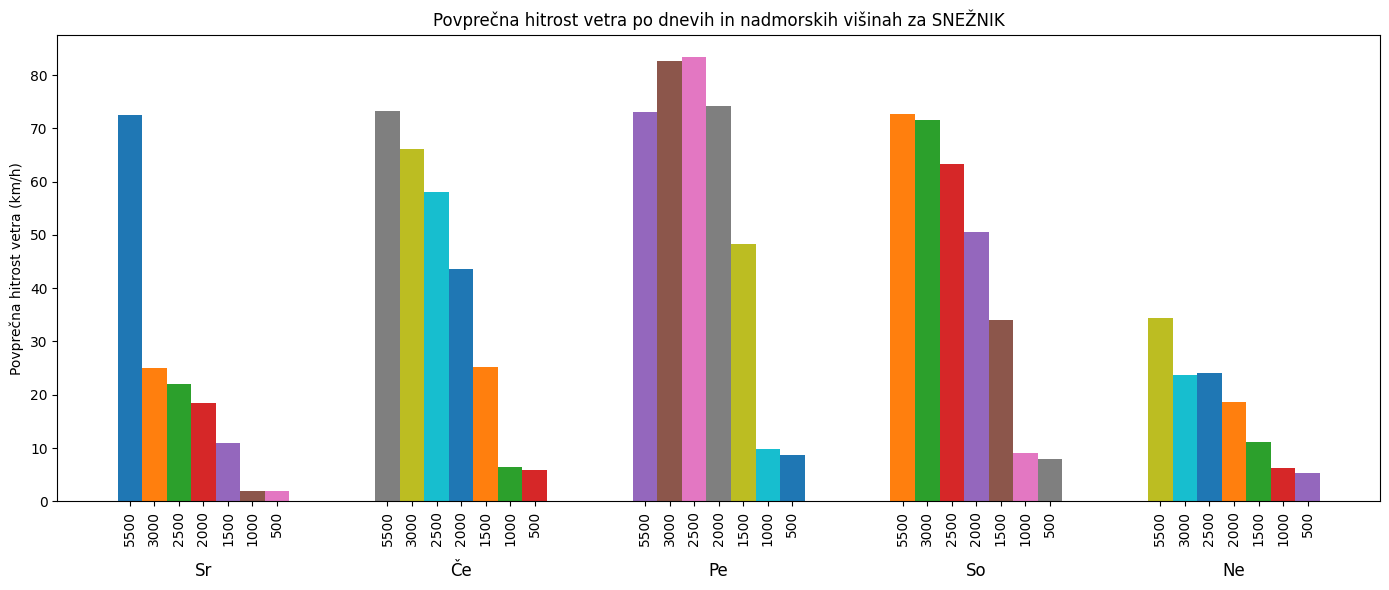

In [19]:
def spreminjanje_hitrosti(gorovje = "vsa gorovja", dan = 4):
    """Funkcija sprejme neobvezna argumenta gorovje in dan (privezi vrednoti: "vsa gorovja", 4) in prikaže kako se hutrost vetra spremi ja z
    nadmorsko višino"""
    
    izbrana_gorovja = seznam_gorovij(gorovje)
    slovar = {}

    for ime_gorovja in izbrana_gorovja:
        veter = zajem_vetra(ime_gorovja)

        opisni_podatki = veter.iloc[0::2].copy().reset_index(drop=True)
        stevilski_podatki = predelaj_podatke_veter(veter.iloc[1::2].copy().reset_index(drop=True))

        opisni_podatki["nadmorska_visina"] = (opisni_podatki.iloc[:, 1].str.extract(r"(\d+)").astype(int))
        
        stevilski_podatki["nadmorska_visina"] = opisni_podatki["nadmorska_visina"]

        nov_df = pd.DataFrame()
        
        #poberemo vse stolpce za vse izbrane dneve, izračunamo povprečje in shranimo v nov data_frame
        for i in range(dan + 1):
            stolpci_dneva = [
                stolpec
                for stolpec in stevilski_podatki.columns
                if str(stolpec).startswith(krajšave[(danes_indeks + i) % 7] + " ")
            ]
            
            if not stolpci_dneva:
                continue

            # vzamemo podatke vseh ur tega dne
            vrednosti = stevilski_podatki[stolpci_dneva].copy()

            nov_df[krajšave[(danes_indeks + i) % 7]] = vrednosti.mean(axis=1)
            nov_df["nadmorska_visina"] = stevilski_podatki["nadmorska_visina"]
            
            slovar[ime_gorovja] = nov_df 
    return slovar

def spreminjanje_hitrosti_graf(slovar):
    for ime_gorovja in slovar:

        # Nadmorske višine
        nadmorske_visine = slovar[ime_gorovja]["nadmorska_visina"].astype(str) 

        # Dnevi so vsi stolpci razen nadmorske višine
        dnevi = slovar[ime_gorovja].columns.drop("nadmorska_visina") 
        n_visin = len(nadmorske_visine)
        n_dni = len(dnevi)  

        # Širina posameznega stolpca
        sirina = 0.8 / n_visin
        plt.figure(figsize=(14, 6))
        polozaji_stolpcev = []  

        # Vsak dan predstavlja svojo skupino.
        # Znotraj skupine so vse nadmorske višine.
        for i, dan in enumerate(dnevi):
            # Začetek skupine za ta dan
            zacetek = i * 1.2
            for j in range(n_visin):
                polozaji_stolpcev.append(zacetek + j * sirina)
                plt.bar(
                    zacetek + j * sirina,
                    slovar[ime_gorovja][dan].iloc[j],
                    width=sirina,
                    label=dan if j == 0 else ""
                )   

        # Sredina vsake skupine (za oznako dneva)
        sredine_skupin = [
            i * 1.2 + (n_visin - 1) * sirina / 2
            for i in range(n_dni)
        ]
        plt.xticks(
        polozaji_stolpcev,
        list(nadmorske_visine) * n_dni,
        rotation=90)  

        # dnevi pod skupinami
        for i, dan in enumerate(dnevi):
            sredina = i * 1.2 + (n_visin - 1) * sirina / 2
            plt.text(sredina,-0.13,dan,transform=plt.gca().get_xaxis_transform(),ha="center",va="top",fontsize=12)
            plt.ylabel("Povprečna hitrost vetra (km/h)")
            plt.title(f"Povprečna hitrost vetra po dnevih in nadmorskih višinah za {ime_gorovja}")
            plt.tight_layout()
        plt.show()

spreminjanje_hitrosti_graf(spreminjanje_hitrosti())

### Interpretacija 22.8.2026
Funkija `pogoste_smeri` je pokazala, da lahko veter v dnevu v izbranem gorovju piha v veliko različnih smeri neba (ena je ponavadi najpogostejša). Funkcija `spreminjanje_hitrosti_graf` pa je pkazala, da veter najhiterje piha na 5500m in naj počasneje na 500m, vmes pa hitrost ne nujno pada z nadmorsko višino.

### Parametrična krivulja vetra
Najprej podatke o smeri in hitrosti vetra s funkcijo `ustvari_vektorje` spremenimo v vektorje, nato izračunamo povprečen vektor za vse nadmorske višine (za določeno meritev) s funkcijo `povprečen vektor` in nato vektorje ponazorimo s parametrično krivuljo d funkcijo `izriši pot`

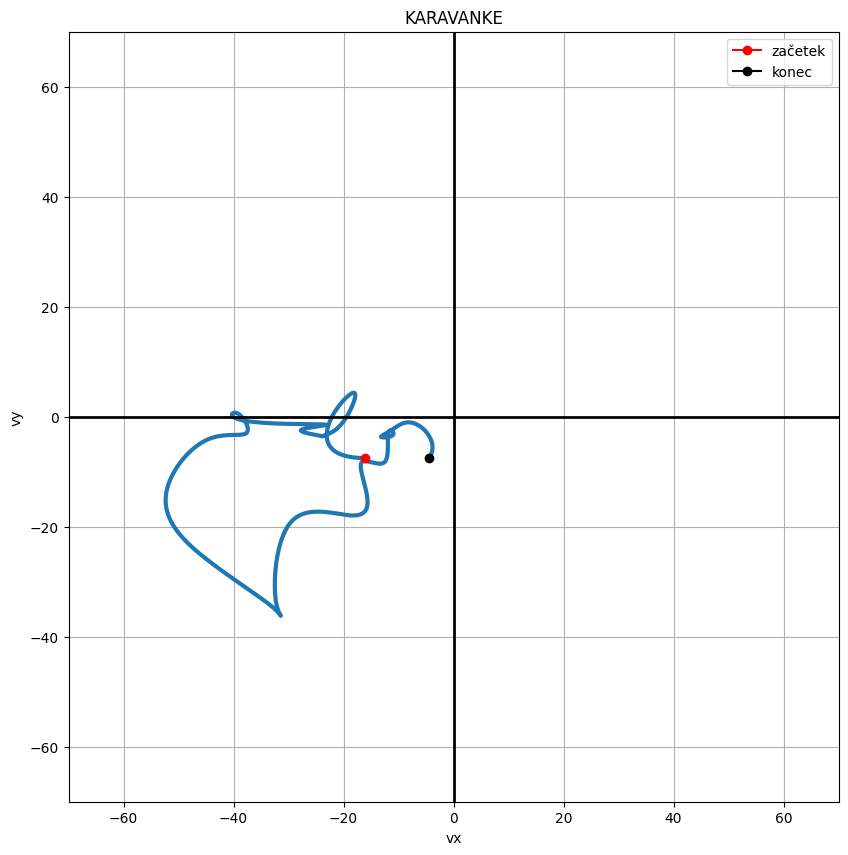

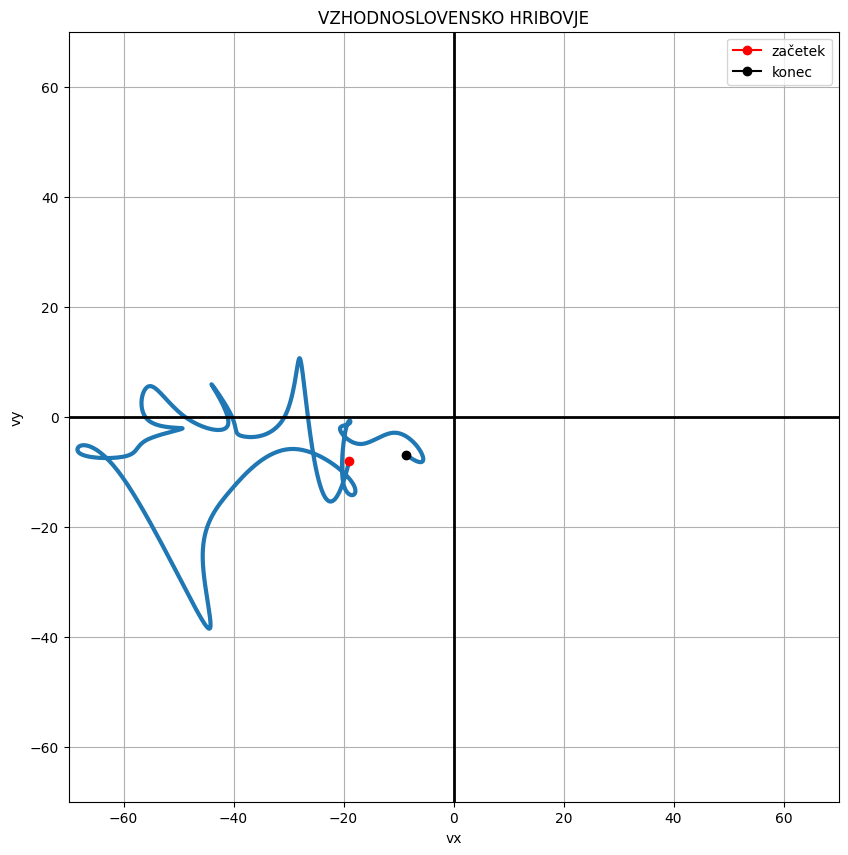

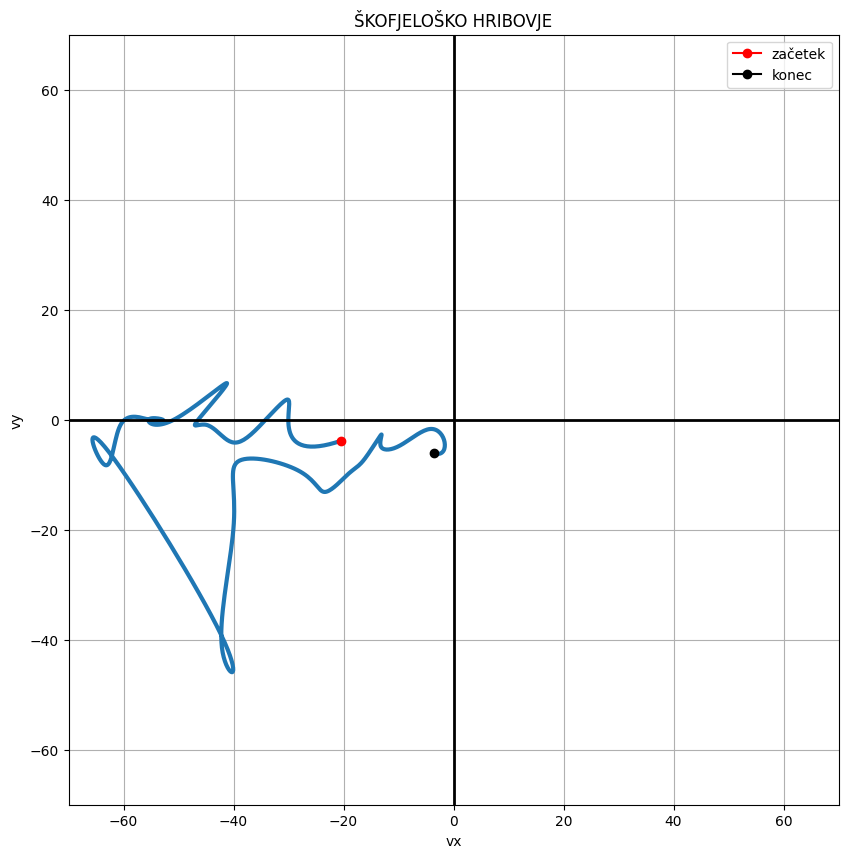

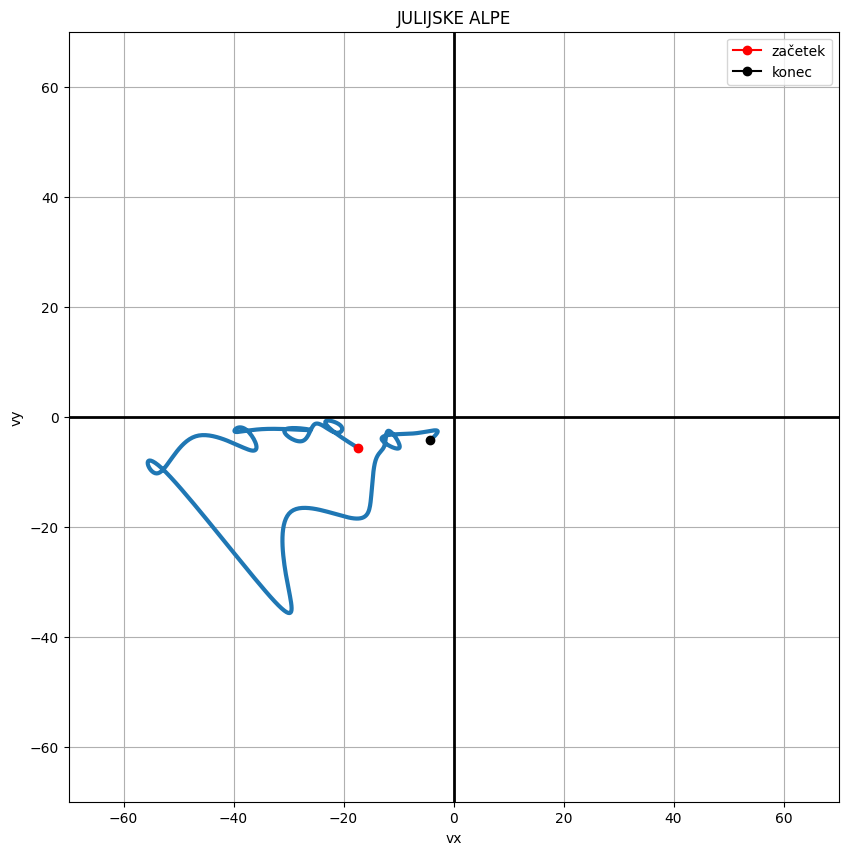

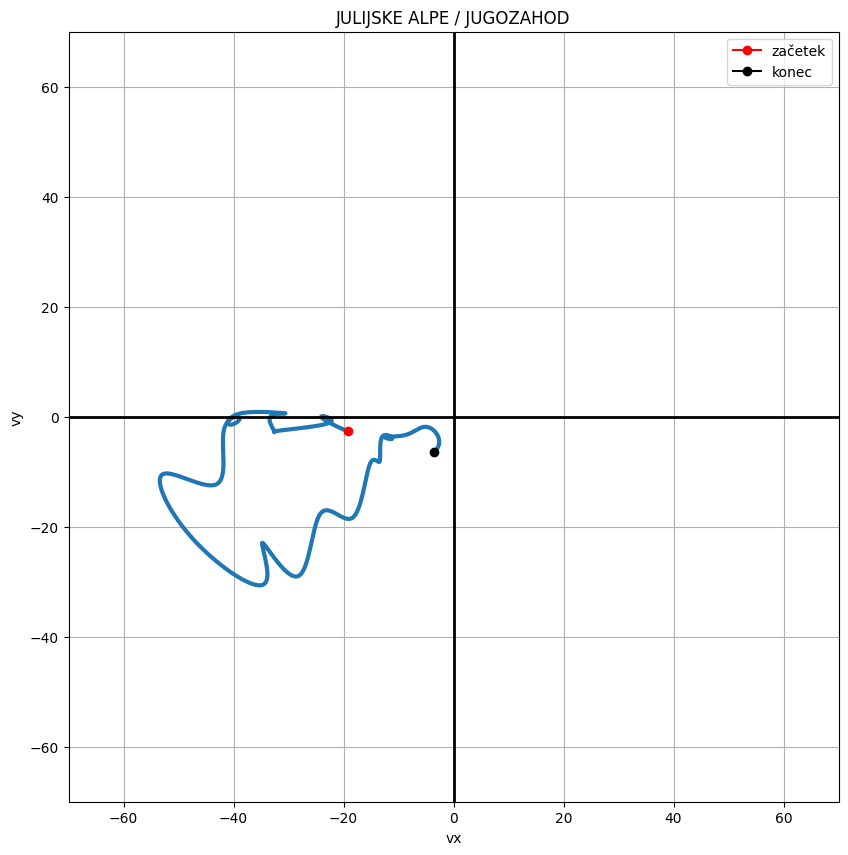

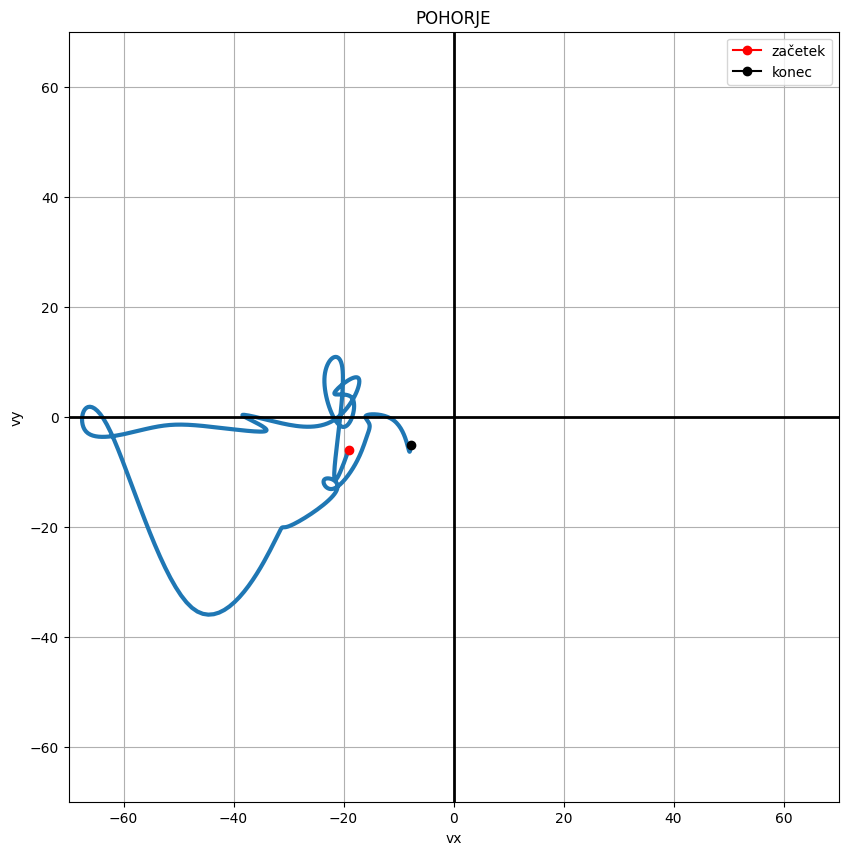

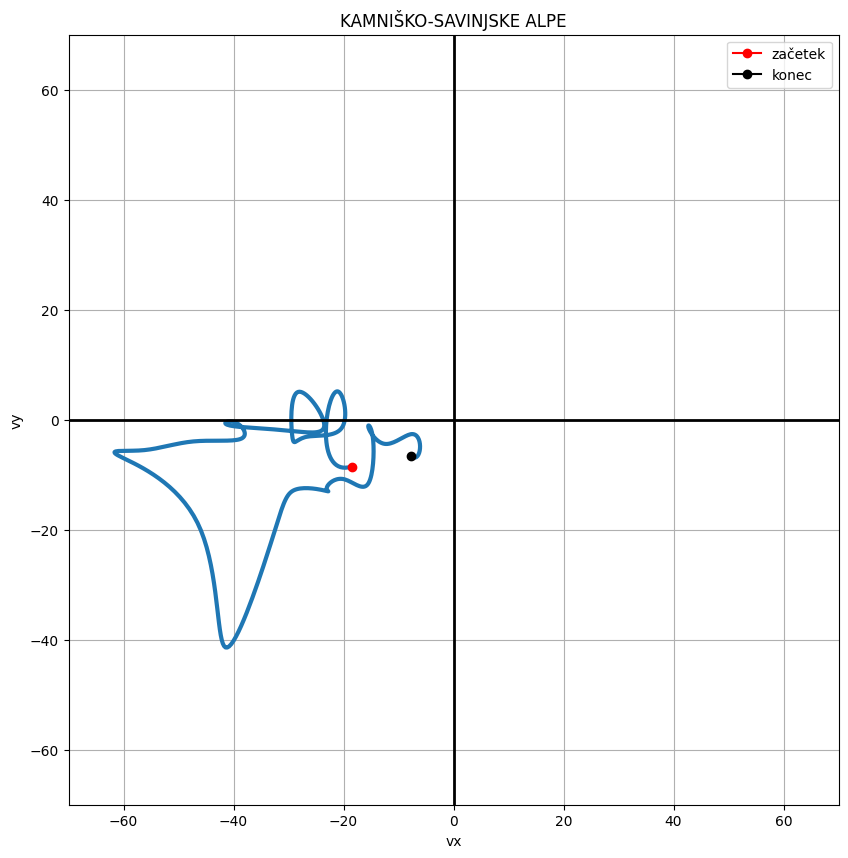

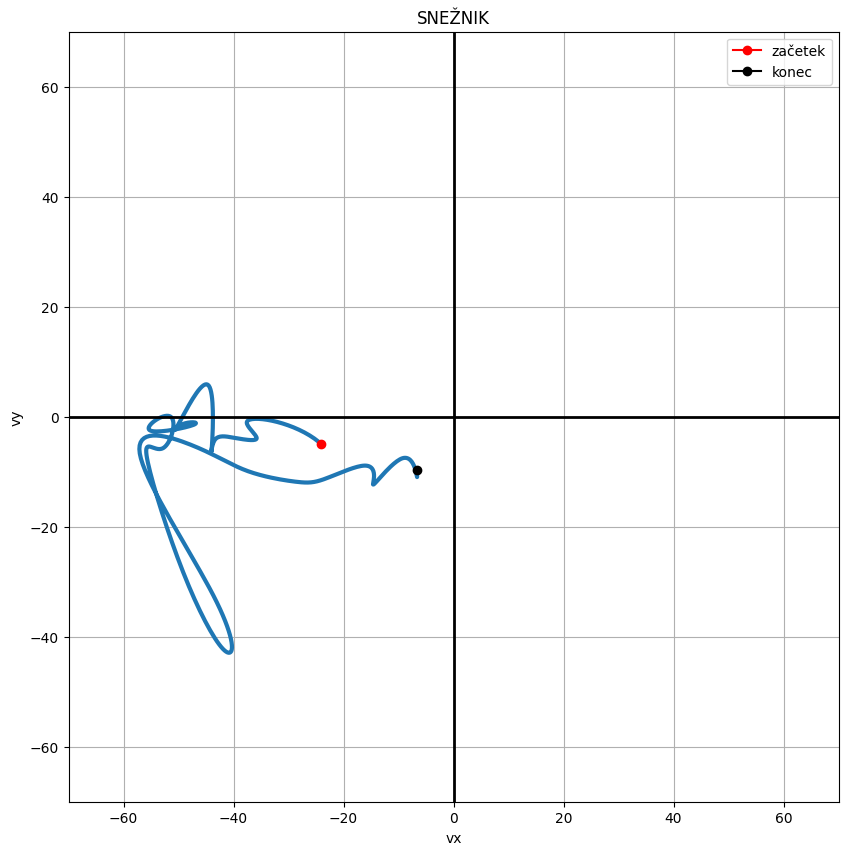

In [31]:
def ustvari_vektorje(veter):
    """Funkcija sprejme podatke o veteru in ustvari vektorje"""
    podatki = veter.iloc[:, 2:]

    smeri = {
        "sever": (0,1),
        "jug": (0, -1),
        "zahod" : (-1, 0),
        "vzhod": (1, 0),
        "severo-zahod": (-np.sqrt(0.5), np.sqrt(0.5)),
        "jugo-zahod": (-np.sqrt(0.5), -np.sqrt(0.5)),
        "severo-vzhod": (np.sqrt(0.5), np.sqrt(0.5)),
        "jugo-vzhod": (np.sqrt(0.5), -np.sqrt(0.5))

    }

    vsi_vektorji = []

    for i in range(0, len(podatki.values), 2):
        vektorji = []
        for j in range(len(podatki.values[i])):
            smerni_vektor = smeri[re.search(r"([\w-]+)$", podatki.values[i][j]).group()]
            velikost = float(re.search(r"\d+", podatki.values[i+1][j]).group())
            vektorji.append((smerni_vektor[0]*velikost,smerni_vektor[1]*velikost))
        vsi_vektorji.append(vektorji)
    return vsi_vektorji

def povprečni_vektorji(vektorji):
    """Funkcija sprejme vektorje in izračuna povprečne vektorje"""
    seznam_povprečij = []

    for i in range(len(vektorji[0])):
        i_ti_vektorji = []
        for seznam in vektorji:
            i_ti_vektorji.append(seznam[i])
        povprecje = (
        sum(x for x, y in i_ti_vektorji) / len(i_ti_vektorji),
        sum(y for x, y in i_ti_vektorji) / len(i_ti_vektorji)
        )
        seznam_povprečij.append(povprecje)

    return seznam_povprečij

def izriši_pot_gorovje(seznam_povprečij, ime_gorovja):

    povprecja = np.array(seznam_povprečij)

    x = povprecja[:, 0]
    y = povprecja[:, 1]
    
    # parameter = zaporedna številka meritve
    t = np.arange(len(povprecja))
    
    # gladki funkciji x(t) in y(t)
    fx = CubicSpline(t, x)
    fy = CubicSpline(t, y)
    
    # veliko vmesnih vrednosti
    t_fino = np.linspace(0, len(povprecja) - 1, 500)
    
    # izračun gladke krivulje
    x_fino = fx(t_fino)
    y_fino = fy(t_fino)
    
    plt.figure(figsize=(10, 10))
    
    # gladka krivulja
    plt.plot(x_fino, y_fino,  linewidth=3)
    
    # meje grafa
    plt.xlim(-70, 70)
    plt.ylim(-70, 70)

    # x in y os skozi (0,0)
    plt.axhline(0, linewidth=2, color = "black")
    plt.axvline(0, linewidth=2, color = "black")

    # označimo začetek in konec
    plt.plot(x[0], y[0], marker="o", color = "red", label = "začetek")
    plt.plot(x[-1], y[-1], marker="o", color = "black", label = "konec")


    # oznake osi
    plt.xlabel("vx")
    plt.ylabel("vy")

    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"{ime_gorovja}")
    plt.legend()

    plt.show()


izbrana_gorovja = seznam_gorovij("vsa gorovja")
for ime_gorovja in izbrana_gorovja:
    povprečja = povprečni_vektorji(ustvari_vektorje(zajem_vetra(ime_gorovja)))[2:]
    izriši_pot_gorovje(povprečja, ime_gorovja)



### Interpretacija 22.8.2026
Smer vetra je večinoma enaka in isto gre za jakost vetra nin to v vseh gorovjih.

## Celostna slika vremena
Funkcija bo vrnila tabelo, ki za izbran prikazuje najpogostejsi vremenski pojav v naslednjih dneh, povprecno temperaturo, vlago in hitrost pihanja vetra ter najpogostejso smer pihanja vetra.

In [21]:
def celostna_slika(gorovje="vsa gorovja"):

    izbrana_gorovja = seznam_gorovij(gorovje)
    for ime_gorovja in izbrana_gorovja:
        napoved = vremenska_napoved(ime_gorovja, 4)[0]

        vrstica_2500 = napoved[napoved.iloc[:, 1].astype(str).str.contains("Vreme na 2500 m")]
        vrstica_1500 = napoved[napoved.iloc[:, 1].astype(str).str.contains("Vreme na 1500 m")]

        if not vrstica_2500.empty:
            vreme_2500 = vrstica_2500.iloc[0, 2:].value_counts().idxmax()
        else:
            vreme_2500 = "ni podatka"
        if not vrstica_1500.empty:
            vreme_1500 = vrstica_1500.iloc[0, 2:].value_counts().idxmax()
        else:
            vreme_1500 = "ni podatka"

        veter = zajem_vetra(ime_gorovja)
        opisni_podatki = veter.iloc[0::2].copy().reset_index(drop=True)
        stevilski_podatki = predelaj_podatke_veter(veter.iloc[1::2].copy().reset_index(drop=True))

        nov_df = pd.DataFrame({
            "ime gorovja": [ime_gorovja] * 7,
            "nadmorska višina": [5500, 3000, 2500, 2000, 1500, 1000, 500],
            "vreme": ["ni podatka", "ni podatka", vreme_2500, "ni podatka", vreme_1500, "ni podatka", "ni podatka"],
            "povprečna temperatura": (predelaj_podatke(zajem_temperature(ime_gorovja)).mean(axis=1).round(2).to_numpy()),
            "povprečna vlaga": (predelaj_podatke_vlaga(zajem_vlage(ime_gorovja)).mean(axis=1).round(2).to_numpy()),
            "najpogostejši veter": opisni_podatki.mode(axis=1)[0].to_numpy(),
            "povprečna hitrost vetra": (stevilski_podatki.mean(axis=1).round(2).to_numpy())
        })
        
        display(nov_df)

celostna_slika()


['KARAVANKE']


,ime gorovja,nadmorska višina,vreme,povprečna temperatura,povprečna vlaga,najpogostejši veter,povprečna hitrost vetra
0,KARAVANKE,5500,ni podatka,-7.13,37.60,močan zahod,62.84
1,KARAVANKE,3000,ni podatka,9.43,52.43,zmeren zahod,46.00
2,KARAVANKE,2500,oblačno,12.57,57.73,močan zahod,40.84
3,KARAVANKE,2000,ni podatka,15.07,68.50,zmeren zahod,27.06
4,KARAVANKE,1500,oblačno,17.20,75.00,rahel jug,10.32
5,KARAVANKE,1000,ni podatka,20.07,71.93,rahel jug,6.00
6,KARAVANKE,500,ni podatka,23.43,79.90,rahel jug,3.19


['VZHODNOSLOVENSKO HRIBOVJE']


,ime gorovja,nadmorska višina,vreme,povprečna temperatura,povprečna vlaga,najpogostejši veter,povprečna hitrost vetra
0,VZHODNOSLOVENSKO HRIBOVJE,5500,ni podatka,-7.03,38.17,močan zahod,61.58
1,VZHODNOSLOVENSKO HRIBOVJE,3000,ni podatka,9.77,50.23,zmeren zahod,53.48
2,VZHODNOSLOVENSKO HRIBOVJE,2500,ni podatka,12.87,53.00,zmeren zahod,49.74
3,VZHODNOSLOVENSKO HRIBOVJE,2000,ni podatka,15.77,58.57,zmeren zahod,43.61
4,VZHODNOSLOVENSKO HRIBOVJE,1500,jasno,18.57,63.30,zmeren zahod,32.65
5,VZHODNOSLOVENSKO HRIBOVJE,1000,ni podatka,21.70,61.10,zmeren zahod,23.10
6,VZHODNOSLOVENSKO HRIBOVJE,500,ni podatka,24.40,58.83,rahel jugo-zahod,9.65


['ŠKOFJELOŠKO HRIBOVJE']


...

,ime gorovja,nadmorska višina,vreme,povprečna temperatura,povprečna vlaga,najpogostejši veter,povprečna hitrost vetra
0,POHORJE,5500,ni podatka,-7.23,37.43,močan zahod,60.42
1,POHORJE,3000,ni podatka,9.70,48.63,zmeren zahod,48.26
2,POHORJE,2500,ni podatka,12.73,52.57,zmeren zahod,43.58
3,POHORJE,2000,ni podatka,15.40,63.23,zmeren jugo-zahod,32.90
4,POHORJE,1500,pretežno oblačno,17.77,69.83,rahel jugo-zahod,20.13
5,POHORJE,1000,ni podatka,20.93,69.97,rahel jugo-zahod,4.81
6,POHORJE,500,ni podatka,24.30,66.90,rahel jugo-zahod,3.97


['KAMNIŠKO-SAVINJSKE ALPE']


,ime gorovja,nadmorska višina,vreme,povprečna temperatura,povprečna vlaga,najpogostejši veter,povprečna hitrost vetra
0,KAMNIŠKO-SAVINJSKE ALPE,5500,ni podatka,-7.07,36.13,močan zahod,63.06
1,KAMNIŠKO-SAVINJSKE ALPE,3000,ni podatka,9.53,51.37,zmeren zahod,48.65
2,KAMNIŠKO-SAVINJSKE ALPE,2500,jasno,12.57,55.13,zmeren zahod,43.52
3,KAMNIŠKO-SAVINJSKE ALPE,2000,ni podatka,15.33,63.00,zmeren zahod,33.10
4,KAMNIŠKO-SAVINJSKE ALPE,1500,jasno,17.63,72.07,rahel jugo-zahod,16.48
5,KAMNIŠKO-SAVINJSKE ALPE,1000,ni podatka,20.83,74.53,rahel jugo-zahod,5.94
6,KAMNIŠKO-SAVINJSKE ALPE,500,ni podatka,24.23,74.63,rahel jugo-zahod,4.16


['SNEŽNIK']


,ime gorovja,nadmorska višina,vreme,povprečna temperatura,povprečna vlaga,najpogostejši veter,povprečna hitrost vetra
0,SNEŽNIK,5500,ni podatka,-6.77,35.37,močan zahod,66.74
1,SNEŽNIK,3000,ni podatka,10.10,49.43,močan zahod,62.32
2,SNEŽNIK,2500,ni podatka,13.33,49.57,močan zahod,58.13
3,SNEŽNIK,2000,ni podatka,16.10,55.27,močan zahod,47.68
4,SNEŽNIK,1500,jasno,18.83,62.20,zmeren jugo-zahod,30.29
5,SNEŽNIK,1000,ni podatka,21.53,69.87,rahel jugo-zahod,7.68
6,SNEŽNIK,500,ni podatka,25.43,67.27,rahel jugo-zahod,6.77


## Zahtevnost razmer
Sestavili bomo funkcije, ki nam bodo pomagale oceniti, kako zahtevne so razmere, glede na vreme, temperaturo in veter (vlaga v tem kontekstu ni bistvena, zato jo bomo supustili).

### Odločitveni model
S funkcijami, ki so spodaj podatkom o vremenu določimo neko številsko vrednost med 0 in 100. Kasneje bomo vsaki kategoriji določili utež. Vreme je vredno 50% ocene, veter 20% in temperatura 30%.

In [28]:
def ocena_vremena(vremenski_pojav):
    """Funkcija sprejme podatke o vremenu in jih ovrednoti"""
    ocene_pojavov_1 = {
        "jasno": 0,
        "pretežno jasno": 0,
        "rahlo oblačno": 25,
        "delno oblačno":25,
        "zmerno oblačno": 50,
        "pretežno oblačno": 75,
        "oblačno": 85,
        "megla" : 50
    }

    ocene_pojavov_2 = {
            "megla": 10 ,
            "rosenje": 10,
            "zmrzujoče rosenje": 30,
            "dež": 20,
            "zmrzujoči dež": 30,
            "dež s snegom": 40,
            "sneg": 50,
            "ploha dežja": 50,
            "ploha dežja s snegom": 70,
            "snežna ploha": 70,
            "ploha sodre": 60,
            "nevihta": 80,
            "nevihta z dežjem": 80,
            "nevihta z dežjem in snegom": 90,
            "nevihta s sneženjem": 90,
            "nevihta s točo": 100
        }

    jakost = {
            "rahel/-lo/-la": 1,
            "zmeren/-no/-na": 1.5,
            "močen/-no/-na": 2
        }

    
    besede = vremenski_pojav.split()
    

    if len(besede) <= 2:
        return ocene_pojavov_1[vremenski_pojav]

    else:
        if besede[0] in ocene_pojavov_1:
            ocena_1 = ocene_pojavov_1[besede[0]]
            ocena_2 = ocene_pojavov_2[" ".join(besede[2:])]
            ocena_jakosti = jakost[besede[1]]
        

        elif " ".join(besede[:2]) in ocene_pojavov_1:

            ocena_1 = ocene_pojavov_1[" ".join(besede[:2])]
            ocena_2 = ocene_pojavov_2[" ".join(besede[3:])]
            ocena_jakosti = jakost[besede[2]]
    
        
    ocena = ocena_1  + ocena_jakosti * ocena_2 

    if ocena < 100:
        return ocena
    else:
        return 100
    
def ocena_vetra(hitrost):
    """Funkcija sprejme podatke o hitrosti in jih ovrednoti"""
    meje = [5, 10, 15, 20, 30, 35, 40, 50, 60]
    ocena = None
    for meja in meje:
        if meja >= hitrost:
            ocena = meje.index(meja) * 10
            break
    return ocena if ocena != None else 100
    

def ocena_temperature(stopinje):
    """Funkcija sprejme podatke o temperaturi in jih ovrednoti"""
    meje = [5, 10, 15, 20]
    razlika = abs(stopinje - 25)
    ocena = None
    for meja in meje:
            if meja >= razlika:
                ocena = meje.index(meja) * 25
                break
    return ocena if ocena != None else 100


### Izračuna zahtevnosti
Dobljen faktor je nekje med 0-100 in pove, kako so po kriterij odločitvenega modela razmere zahtevne. Višji kot je faktor tem ugodnejše so razmere.

In [30]:
def zahtevnost_razmer(gorovje = "vsa gorovja"):
    """Funcija sprejme neobvezen argument gorovje (privzeta vrednost: "vsa gorovja") in izračuna zahtevnost_razmer"""

    izbrana_gorovja= seznam_gorovij(gorovje)

    for ime_gorovja in izbrana_gorovja:

        # zajamemo potrebne podatke za izbrano gorovje
        vreme = df[(df.iloc[:, 0].astype(str).eq(ime_gorovja)) &(df.iloc[:, 1].astype(str).str.fullmatch(r"Vreme na \d+ m"))] 
        temperatura = zajem_temperature(ime_gorovja)
        veter = zajem_vetra(ime_gorovja)[1::2].reset_index(drop=True)

        # to vrstico dodamo na konec saj predelaj podatke vzame iz temperature vse do predzadnjega stolpca
        temperatura["nadmorska visina"] = [5500, 3000, 2500, 2000, 1500, 1000, 500]

        # podatke pretvorimo v številke
        temp_podatki = predelaj_podatke(temperatura)
        temp_podatki["nadmorska visina"] = [5500, 3000, 2500, 2000, 1500, 1000, 500]

        veter_podatki = predelaj_podatke_veter(veter)
        veter_podatki["nadmorska visina"] = [5500, 3000, 2500, 2000, 1500, 1000, 500]

        
        nov_df = pd.DataFrame()

        # nekatera gorovja nimajo podatka o vremenu na 2500m ker niso tako visoka
        if len(vreme) == 2:
            nov_df["gorovje"] = [ime_gorovja, ime_gorovja]
            nov_df["nadmorska visina"] = [2500, 1500]
            seznam_visin = [2500, 1500]
        elif len(vreme) == 1:
            nov_df["gorovje"] = [ime_gorovja]
            nov_df["nadmorska visina"] = [1500]
            seznam_visin = [1500]

        # za 1 ali 2 vrstici v data framu izračunamo indeks
        for i, visina in enumerate(seznam_visin):
            obr_vreme = vreme.iloc[i][2:]
            obr_temp = temp_podatki[temp_podatki["nadmorska visina"] == visina].iloc[0][:-1]
            obr_veter = veter_podatki[veter_podatki["nadmorska visina"] == visina].iloc[0][:-1]
           
            for stolpec in obr_vreme.index:
                indeks = 100-(ocena_vremena(obr_vreme[stolpec]) * 0.5 + ocena_temperature(obr_temp[stolpec]) * 0.3 + ocena_vetra(obr_veter[stolpec]) * 0.2)
                nov_df.loc[i, stolpec] = indeks
        display(nov_df)

zahtevnost_razmer()

,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,KARAVANKE,2500,38.5,34.5,77.0,77.0,79.0,39.5,68.0,35.5,...,17.5,22.0,56.5,49.0,59.0,27.0,29.0,31.0,63.0,71.0
1,KARAVANKE,1500,46.0,48.0,88.5,90.5,90.5,53.0,78.0,60.5,...,33.0,45.0,68.0,70.0,78.0,42.5,42.5,50.0,72.5,80.5


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,VZHODNOSLOVENSKO HRIBOVJE,1500,51.0,46.0,49.0,84.5,82.5,66.0,72.0,52.5,...,47.0,39.0,76.5,74.0,88.5,88.5,88.5,78.0,90.5,80.5


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,ŠKOFJELOŠKO HRIBOVJE,1500,49.0,44.0,88.5,84.5,82.5,40.0,70.0,43.0,...,39.0,39.0,76.0,76.0,90.5,90.5,80.0,76.0,90.5,68.0


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,JULIJSKE ALPE,2500,38.5,34.5,77.0,77.0,77.0,37.5,64.5,41.0,...,17.5,22.0,51.0,26.0,49.0,27.0,29.0,36.0,28.0,51.0
1,JULIJSKE ALPE,1500,48.0,48.0,90.5,90.5,90.5,55.0,85.5,58.5,...,42.5,45.0,70.0,45.0,62.5,42.5,42.5,47.5,45.0,70.0


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,JULIJSKE ALPE / JUGOZAHOD,2500,36.5,34.5,77.0,75.0,77.0,28.5,33.5,41.0,...,49.5,64.0,49.0,49.0,69.5,69.5,34.0,63.0,30.0,73.0
1,JULIJSKE ALPE / JUGOZAHOD,1500,48.0,48.0,90.5,90.5,90.5,48.0,51.0,51.0,...,61.0,73.5,68.0,68.0,90.5,90.5,55.0,80.0,43.0,80.5


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,POHORJE,1500,86.5,46.0,49.0,84.5,84.5,78.0,53.0,83.5,...,33.5,35.0,75.5,53.0,88.5,88.5,88.5,55.0,70.0,65.0


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,KAMNIŠKO-SAVINJSKE ALPE,2500,36.5,34.5,75.0,77.0,77.0,66.5,70.0,60.5,...,25.0,25.0,67.0,57.0,69.5,69.5,71.5,36.0,26.0,64.0
1,KAMNIŠKO-SAVINJSKE ALPE,1500,44.0,44.0,86.5,88.5,88.5,78.0,76.0,76.0,...,38.5,38.5,78.5,76.0,88.5,90.5,90.5,55.0,43.0,75.5


,gorovje,nadmorska visina,Sr 20 CEST,Sr 23 CEST,Če 02 CEST,Če 05 CEST,Če 08 CEST,Če 11 CEST,Če 14 CEST,Če 17 CEST,...,So 11 CEST,So 14 CEST,So 17 CEST,So 20 CEST,So 23 CEST,Ne 02 CEST,Ne 05 CEST,Ne 08 CEST,Ne 11 CEST,Ne 14 CEST
0,SNEŽNIK,1500,53.0,76.0,88.5,86.5,84.5,47.0,74.0,47.0,...,47.0,47.0,47.0,84.5,88.5,90.5,90.5,90.5,88.5,88.5


### Splošno stanje v slovenskih gorovjih

In [24]:
temperatura = []
vlaga = []
veter_smer = []
veter_hitrost = []

for gorovje in seznam_gorovij("vsa gorovja"):
    temperatura.append(zajem_temperature(gorovje).iloc[:, 2:].copy().replace(r" °C", "", regex=True).astype(float))
    vlaga.append(zajem_vlage(gorovje).iloc[:, 2:].copy().replace(r" %", "", regex=True).astype(float))
    veter_smer.append(zajem_vetra(gorovje)[0::2])
    veter_hitrost.append(zajem_vetra(gorovje)[1::2].iloc[:, 2:].copy().replace(r" km/h", "", regex=True).astype(float))

temp_skupaj = pd.concat(temperatura, ignore_index=True)
vlaga_skupaj = pd.concat(vlaga, ignore_index=True)
veter_s_skupaj = pd.concat(veter_smer, ignore_index=True)
veter_h_skupaj = pd.concat(veter_hitrost, ignore_index=True)


print(f"Povprečna temperatura v vseh slovenskih gorovjih skupaj je {temp_skupaj.stack().mean():.2f} °C")
print(f"Povprečna vlaga v vseh slovenskih gorovjih skupaj je {vlaga_skupaj.stack().mean():.2f} %")
print(f"Povprecna hitrost vetra v slovenskih gorovjih je {veter_h_skupaj.stack().mean():.2f} km/h")
print(f"Povprecna smer vetra v slovenskih gorovjih je \"{veter_s_skupaj.stack().mode()[0]}\"")



Povprečna temperatura v vseh slovenskih gorovjih skupaj je 13.27 °C
Povprečna vlaga v vseh slovenskih gorovjih skupaj je 60.53 %
Povprecna hitrost vetra v slovenskih gorovjih je 32.80 km/h
Povprecna smer vetra v slovenskih gorovjih je "zmeren zahod"


## Zaključek

Z analizo podatkov o vremenu v slovenskih gorovjih smo ugotovili:
- temperatura se v vsakem gorovju bistveno spreminja za nadmorsko višino
- 22.8. (ko sem pogledala podatke) izgleda da se temperatura na vseh nadmorskih višinah spreminja približno enako (lomljenke so vzporedne)
- 22.8. (ko sem pogledala podatke) izgleda da se vlaga s časom zelo spreminja, lomljenke imajo veliko skoke in si niso vzporedne
- 22.8. (ko sem pogledala podatke) izgleda da, da vlaga s nadmorsko višino ne niha toliko kot časovno
- 26.8. (ko sem pogledala podatke) izgleda da ni konkretne korelacije med vlago in temperaturp
- 26.8. (ko sem pogledala podatke) izgleda da v dnevu ne prevaduje ena konkretna smer v katero piha veter
- 26.8. (ko sem pogledala podatke) izgleda da hitrost vetra pada z nadmorsko višino
- 26.8. (ko sem pogledala podatke) iz parametrične krivulje ne morem narediti konkretnega zaključka. Nagibam se k temu, da se smer vetra ne spreminja konkretno.

